In [ ]:
pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 860.5 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.4 MB/s eta 0:00:00
  Created wheel for sentence-transformers: filename=sentence_transformers-2.2.2-py3-none-any.whl size=125923 sha256=0c93af0e60fb92ebdb965a6e48279937ca40791a63e52d328b4e352895ff8e83
  Stored in directory: /root/.cache/pip/wheels/62/f2/10/1e606fd5f02395388f74e7462910fe851042f97238cbbd902f
Successfully built sentence-transformers


In [ ]:
#Importing Libraries
import pandas as pd #to read data
import numpy as np #to perform mathematical operartions
import re #for string formatting
import nltk #for text pre processing
import matplotlib.pyplot as plt #to plot graphs
from sentence_transformers import SentenceTransformer #for generating embeddings
import tensorflow as tf #to create DNN
import keras #to make API calls for DNN
from sklearn.model_selection import train_test_split #to split dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score #to evaluate models
import torch #for tensors
import random
#to reproduce results
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
#reading data
pd.set_option("display.width",1000)
pd.set_option('display.expand_frame_repr', False)
df_train = pd.read_csv("/content/bulgarian/Hope_Bulgarian_train.tsv",sep='\t',index_col = 0)#training script
df_dev = pd.read_csv("/content/bulgarian/Hope_Bulgarian_dev.tsv",sep='\t',index_col = 0)#development script
df_test = pd.read_csv("/content/bulgarian/Hope_Bulgarian_test_with_labels.tsv",sep='\t',index_col = 0)

In [ ]:
df_train

,Comment,Hope_Speech
ID,,
57415_11,"Вечерята спира, \nракията изстива,\nно видеото...",False
56672_77,"След тези видеа, всеки с име Румен Симеонов ил...",False
34113_654,Интересно как министърът на младежта и спорта ...,False
42542_384,"Ама айди по-честичко, де",False
23939_1462,няма да стане нищо Русия се подцениха на ден и...,False
...,...,...
60989_1336,Задаваш въпроси на базата на филм. За кое чете...,False
7150_21,"а оназ с кафевото, коженкото жакетче. С тънкит...",False
49261_509,Дария Желязкова и аз.,False


In [ ]:
df_dev

,Comment,Hope_Speech
ID,,
32130_603,"За да не бъде ""копиран"" от ""доброжелатели"" вер...",False
45471_662,@user не е качвал от 2020г. Моляяяявя,False
69965_282,"На 14 съм и ми е 14,5 добре ли е?",False
44839_30,"Пръснах се от смях, @user!\nНищо, че качваш ря...",False
70902_19,НА СЛАДКАРНИЦА. върши работа :),False
...,...,...
13637_557,това време никога няма да се върне бях на 11-1...,False
45905_55,"""Така ли смръдльо?""",False
49775_178,"""На изток от рая"" - имах усещане за нещо лично...",False


In [ ]:
df_test

,Comment,Hope_Speech
ID,,
73316_0,"Продължавай да правиш видеа, ще са много полез...",False
61669_23,Направи клип признаци че сте в пубертета ! МОЛЯ !,False
55493_6,Не съм и очаквала нещо по-малко. Личи му на @u...,True
21865_525,Ей добре бе @userка мъж на 17 години съм ревах...,True
60787_1134,"Получил си свобода, избор, възможности. \n\nТо...",False
...,...,...
38091_321,"@user, направи канал с шорт хот глипове от тез...",False
57588_2,Никой никога не ви беше казвал истината поднес...,False
58155_387,"Г-н @user народът е казал: ""Прекаления светец ...",False


In [ ]:
df = pd.concat([df_train,df_dev],axis = 0 )
category_counts = df['Hope_Speech'].value_counts()
category_counts

False    4962
True      298
Name: Hope_Speech, dtype: int64

In [ ]:
category_counts = df_test['Hope_Speech'].value_counts()
category_counts

False    449
True     150
Name: Hope_Speech, dtype: int64

In [ ]:
pip install imbalanced-learn

In [ ]:
pip install pyspellchecker

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 17.5 MB/s eta 0:00:00


# Oversampling using Random Oversampling and CBOW

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['Comment']
y_train = df['Hope_Speech']

# Step 2: Create an instance of RandomOverSampler
oversampler = RandomOverSampler(random_state=42)

# Step 3: Tokenize the text data
def tokenize_text(x):
    return x.split() if isinstance(x, str) else []

X_train_tokenized = X_train.apply(tokenize_text)

# Step 4: Fit and apply RandomOverSampler only on the training data
X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the oversampled training data
model = Word2Vec(sentences=X_train_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_oversampled back to string format
X_train_oversampled_strings = [' '.join(sentence) for sentence in X_train_oversampled[:, 0]]

# Step 7: Print the distribution of the oversampled training data
print("Distribution of oversampled training data:")
print(pd.Series(y_train_oversampled).value_counts())

# Now, X_train_oversampled_strings contains the oversampled strings
# You can use it for training.

# Step 8: Update df with oversampled values
df_oversampled = pd.DataFrame({'Text': X_train_oversampled_strings, 'labels': y_train_oversampled})

# Now, df_oversampled contains the oversampled values. You can use it for training.


Distribution of oversampled training data:
False    4962
True     4962
Name: Hope_Speech, dtype: int64


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec
import pandas as pd

X_test = df_test['Comment']
y_test = df_test['Hope_Speech']

oversampler = RandomOverSampler(random_state=42)

X_test_tokenized = X_test.apply(lambda x: x.split())

X_test_oversampled, y_test_oversampled = oversampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_oversampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_oversampled_strings = [' '.join(sentence) for sentence in X_test_oversampled[:, 0]]

print("Distribution of resampled training data:")
print(pd.Series(y_test_oversampled).value_counts())

df_test_oversampled = pd.DataFrame({'Text': X_test_oversampled_strings, 'labels': y_test_oversampled})


Distribution of resampled training data:
False    449
True     449
Name: Hope_Speech, dtype: int64


In [ ]:
df_oversampled

,Text,labels
0,"Вечерята спира, ракията изстива, но видеото на...",False
1,"След тези видеа, всеки с име Румен Симеонов ил...",False
2,Интересно как министърът на младежта и спорта ...,False
3,"Ама айди по-честичко, де",False
4,няма да стане нищо Русия се подцениха на ден и...,False
...,...,...
9919,"Правете още клипове заедно, много добре ви се ...",True
9920,Уникален си,True
9921,Станиславе голям мъж съм но успя да ме разплач...,True
9922,Благодаря ти за това което правиш! Майка ми и ...,True


In [ ]:
df_test_oversampled

,Text,labels
0,"Продължавай да правиш видеа, ще са много полез...",False
1,Направи клип признаци че сте в пубертета ! МОЛЯ !,False
2,Не съм и очаквала нещо по-малко. Личи му на @u...,True
3,Ей добре бе @userка мъж на 17 години съм ревах...,True
4,"Получил си свобода, избор, възможности. Това ч...",False
...,...,...
893,"@user, голям си! Продължавай в същия дух. По-д...",True
894,Голяма работа си Любо!,True
895,Браво само напред !,True
896,"Аааааа не, само като видях началото и знаех, ч...",True


# Undersampling using Random undersampling and Continuous Bag of words

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split

# Assuming df and df_test are your original DataFrames
# You might need to adjust the column names based on your actual DataFrames

# Step 1: Separate features and labels for the training set
X_train = df['Comment']
y_train = df['Hope_Speech']

# Step 2: Create an instance of RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Step 3: Tokenize the text data
def tokenize_text(x):
    return x.split() if isinstance(x, str) else []

X_train_tokenized = X_train.apply(tokenize_text)

# Step 4: Fit and apply RandomUnderSampler only on the training data
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train_tokenized.values.reshape(-1, 1), y_train)

# Step 5: Train Word2Vec on the undersampled training data
model = Word2Vec(sentences=X_train_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

# Step 6: Convert X_train_undersampled back to string format
X_train_undersampled_strings = [' '.join(sentence) for sentence in X_train_undersampled[:, 0]]

# Step 7: Print the distribution of the undersampled training data
print("Distribution of undersampled training data:")
print(pd.Series(y_train_undersampled).value_counts())

# Now, X_train_undersampled_strings contains the undersampled strings
# You can use it for training.

# Step 8: Update df with undersampled values
df_undersampled = pd.DataFrame({'Text': X_train_undersampled_strings, 'labels': y_train_undersampled})

# Step 9: Separate features and labels for the testing set
X_test = df_test['Comment']
y_test = df_test['Hope_Speech']

# Step 10: for the testing data
X_test_tokenized = X_test.apply(lambda x: x.split())
X_test_undersampled, y_test_undersampled = undersampler.fit_resample(X_test_tokenized.values.reshape(-1, 1), y_test)

model = Word2Vec(sentences=X_test_undersampled[:, 0], vector_size=100, window=5, min_count=1, workers=4)

X_test_undersampled_strings = [' '.join(sentence) for sentence in X_test_undersampled[:, 0]]
df_test_undersampled = pd.DataFrame({'Text': X_test_undersampled_strings, 'labels': y_test_undersampled})

# Step 11: Print the distribution of the original testing data
print("\nDistribution of original testing data:")
print(y_test_undersampled.value_counts())



Distribution of undersampled training data:
False    298
True     298
Name: Hope_Speech, dtype: int64

Distribution of original testing data:
False    150
True     150
Name: Hope_Speech, dtype: int64


In [ ]:
df_undersampled

,Text,labels
0,"@user по принцип не е лош човек, личи му. Лошо...",False
1,"Мале как си приличате, докато разбера какво се...",False
2,Яко е Браво !,False
3,Тука @user ми напомня на моментите в училище к...,False
4,не мога да повярвам че това е 2-рия клип за 1 ...,False
...,...,...
591,Ем. Продължи по своя път. Има още много момиче...,True
592,"Да, до ген е. Няма проблем, даже по-малко разп...",True
593,Трябва да бъдем всеки ден по-добри,True
594,"Няма смисъл да се притесняваш! {Има хора, коит...",True


In [ ]:
df_test_undersampled

,Text,labels
0,@user Важното е да сме живи и здрави,False
1,Песнисът ми е голям 26см На 16 години съм,False
2,"То ясно що за птица е човек, който смята Горба...",False
3,Тоя ги разби човек,False
4,Iwailo Btchs евала братленце,False
...,...,...
295,Изборът си е изцяло твой. Изобщо не е странно....,True
296,"Аз просто си го бях наумил още от 7 клас, че щ...",True
297,Браво желая ти дълголетие в тези среди ! Получ...,True
298,"Евала Цветославе :) Ти си единствения влогър,к...",True


# Preprocessing

In [ ]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import string
import math
from spellchecker import SpellChecker
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
# creating functions for each task
def split_attached_words(text):
    #attached words look like #PeaceForUkraine
    text = text.replace("#", "")
    pattern = r'([А-Я][а-я]+|[а-я]+)(?=[А-Я])'
    split_text = re.sub(pattern, r'\1 ', text)

    return split_text
#expanding contractions
def decontracted(text):
    # Bulgarian contractions (example: няма да -> няма да)
    contractions = {
        "няма да": "няма да",
        "няма да": "няма да",
    }

    # Replace contractions
    for contraction, expanded_form in contractions.items():
        text = re.sub(contraction, expanded_form, text)

    return text

def preprocess(text):
#lower case the data (text):
    text = text.lower()
#remove numbers and words containing numbers
    text = re.sub('\w*\d\w*','', text)
# Remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    text_without_html = soup.get_text(separator=" ")
# Remove other links (e.g., URLs)
    text = re.sub(r'http\S+|www.\S+', '', text_without_html)
#remove punctuations
    translator = str.maketrans("", "", string.punctuation)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.translate(translator)
#stopwords removal
    stop_words = set(stopwords.words('english')) # you can download the stopwords of the language you are working on
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    text = ' '.join(filtered_tokens)
    return text
#stemming of the text
def lemmatize(text):
    #You can use snowball stemmer for different languages like hindi
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    text = " ".join(lemmatized_tokens)
    return text
def substitute_emojis(text, replacement="[EMOJI]"):
    # Define the emoji pattern using Unicode blocks
    emoji_pattern = re.compile("[\U0001F600-\U0001F64F\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF"
                               "\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+", flags=re.UNICODE)

    # Substitute emojis with the replacement text
    text = emoji_pattern.sub(replacement, text)

    return text

In [ ]:
# Applying function on data to clean the text
df_undersampled["Text"] = df_undersampled["Text"].apply(split_attached_words)
df_undersampled["Text"] = df_undersampled["Text"].apply(decontracted)
df_undersampled["Text"] = df_undersampled["Text"].apply(preprocess)
df_undersampled["Text"] = df_undersampled["Text"].apply(substitute_emojis)
df_undersampled["Text"] = df_undersampled["Text"].apply(lemmatize)

<ipython-input-15-1511b3f4ca10>:36: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
# Applying function on data to clean the text
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(split_attached_words)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(decontracted)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(preprocess)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(substitute_emojis)
df_test_undersampled["Text"] = df_test_undersampled["Text"].apply(lemmatize)

<ipython-input-15-1511b3f4ca10>:36: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [ ]:
df_undersampled

,Text,labels
0,user по принцип не е лош човек личи му лошото ...,False
1,мале как си приличате докато разбера какво се ...,False
2,яко е браво,False
3,тука user ми напомня на моментите в училище ко...,False
4,не мога да повярвам че това е рия клип за седм...,False
...,...,...
591,ем продължи по своя път има още много момичета...,True
592,да до ген е няма проблем даже помалко разправи...,True
593,трябва да бъдем всеки ден подобри,True
594,няма смисъл да се притесняваш има хора които с...,True


In [ ]:
df_test_undersampled

,Text,labels
0,user важното е да сме живи и здрави,False
1,песнисът ми е голям на години съм,False
2,то ясно що за птица е човек който смята горбач...,False
3,тоя ги разби човек,False
4,iwailo btchs евала братленце,False
...,...,...
295,изборът си е изцяло твой изобщо не е странно н...,True
296,аз просто си го бях наумил още от клас че ще с...,True
297,браво желая ти дълголетие в тези среди получав...,True
298,евала цветославе ти си единствения влогъркойто...,True


In [ ]:
def remove_extra_whitespaces(text):
  # Replace all consecutive whitespaces with a single space.
  text = re.sub(r'\s+', ' ', text)

  # Remove leading and trailing whitespaces.
  text = text.strip()

  return text
df_undersampled['Text'] = df_undersampled['Text'].apply(remove_extra_whitespaces)
df_test_undersampled['Text'] = df_test_undersampled['Text'].apply(remove_extra_whitespaces)

In [ ]:
df_undersampled['Text']

0      user по принцип не е лош човек личи му лошото ...
1      мале как си приличате докато разбера какво се ...
2                                            яко е браво
3      тука user ми напомня на моментите в училище ко...
4      не мога да повярвам че това е рия клип за седм...
                             ...                        
591    ем продължи по своя път има още много момичета...
592    да до ген е няма проблем даже помалко разправи...
593                    трябва да бъдем всеки ден подобри
594    няма смисъл да се притесняваш има хора които с...
595    user правиш много итерсни видеа забавни и мног...
Name: Text, Length: 596, dtype: object

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
labels = list(df_undersampled["labels"])
labels_reshaped = [label for label in labels]
encoder.fit(labels_reshaped)
Target= encoder.transform(labels_reshaped) # this will remain target for each of the classification task

In [ ]:
X_train, X_test, y_train = df_undersampled['Text'],df_test_undersampled['Text'],Target

In [ ]:
from scipy import sparse as sp_sparse
# Dictionary of all words from train corpus with their counts.
words_counts = {}
for comments in X_train:
    for word in comments.split():
        if word not in words_counts:
            words_counts[word] = 1
        words_counts[word] += 1

DICT_SIZE = 10000
POPULAR_WORDS = sorted(words_counts, key=words_counts.get, reverse=True)[:DICT_SIZE]
WORDS_TO_INDEX = {key: rank for rank, key in enumerate(POPULAR_WORDS, 0)}
INDEX_TO_WORDS = {index:word for word, index in WORDS_TO_INDEX.items()}
ALL_WORDS = WORDS_TO_INDEX.keys()

# Bag of Words vectorisation

In [ ]:
def my_bag_of_words(text, words_to_index, dict_size):
    """
        text: a string
        dict_size: size of the dictionary

        return a vector which is a bag-of-words representation of 'text'
    """
    result_vector = np.zeros(dict_size)
    for word in text.split(' '):
        if word in words_to_index:
            result_vector[words_to_index[word]] +=1
    return result_vector

X_train_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_train])
X_test_mybag = sp_sparse.vstack([sp_sparse.csr_matrix(my_bag_of_words(text, WORDS_TO_INDEX, DICT_SIZE)) for text in X_test])
print('X_train shape ', X_train_mybag.shape, '\nX_val shape ', X_test_mybag.shape)

X_train shape  (596, 10000) 
X_val shape  (300, 10000)


# TF-IDF vectorisation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def tfidf_features(X_train, X_test):
    """
        X_train, X_test — samples
        return TF-IDF vectorized representation of each sample and vocabulary
    """
    # Create TF-IDF vectorizer with a proper parameters choice
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2), max_df=0.9, min_df=5)#, token_pattern='(\S+)')
    # Fit the vectorizer on the train set
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    # Transform the train, test set and return the result
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    return X_train_tfidf,  X_test_tfidf, tfidf_vectorizer.vocabulary_,tfidf_vectorizer.get_feature_names_out()

X_train_tfidf, X_test_tfidf, tfidf_vocab,feature_names_tfidf = tfidf_features(X_train, X_test)
tfidf_reversed_vocab = {i:word for word,i in tfidf_vocab.items()}

In [ ]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 4.6 MB/s eta 0:00:00


# Explainable AI function

In [ ]:
# import shap

# def explainable_AI(model,X_train,feature_names,X_test,ShapExplainer,flag = True):
#     explainer = ShapExplainer(model,X_train,feature_names=feature_names)
#     shap_values = explainer.shap_values(X_test)
#     print("Summary plot as a whole:")
#     shap.summary_plot(shap_values, X_test,feature_names=feature_names,class_names=['false','true'])
#     print()
#     if flag:
#         print()
#         print("Summary plot for \'not hope\'")
#         shap.summary_plot(shap_values[0], X_test_tfidf,feature_names=feature_names_tfidf)
#         print()
#         print("Summary plot for \'hope\'")
#         shap.summary_plot(shap_values, X_test_tfidf,feature_names=feature_names_tfidf)
#         print()

#     return explainer,shap_values

import shap
import numpy as np
from scipy import sparse as sp

def explainable_AI(model, X_train, feature_names, X_test, ShapExplainer, flag=True):
    explainer = ShapExplainer(model, X_train, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test)

    # Convert shap_values to a 2D matrix
    shap_values_matrix = np.vstack(shap_values)

    # Convert sparse matrix to dense matrix for shap.summary_plot
    X_test_dense = X_test.toarray() if sp.issparse(X_test) else X_test

    print("Summary plot as a whole:")
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['false', 'true'])
    print()
    shap.summary_plot(shap_values_matrix, X_test_dense, feature_names=feature_names, class_names=['false', 'true'],plot_type='bar')
    print()

    return explainer, shap_values

In [ ]:
def forcePlotforParticularDataPoint(explainer,shap_values,X_test,feature_names,i):
    return shap.force_plot(explainer.expected_value[0], shap_values, X_test.toarray()[i], feature_names=feature_names)

# Convert test labels to numeric form

In [ ]:
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv",index_col = 0)
y_true = df_test_undersampled['labels']
# Assuming df_test_labels contains the true labels for the test set
# Convert the labels in y_true to numeric values if needed
# For example, if 'HS' is 1 and 'NHS' is 0
y_true_numeric = encoder.transform(y_true)
y_true_numeric

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
#Importing Machine Learning Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB

# Classifier Models

# Random Forest Classifier

In [ ]:
tfidf_model = RandomForestClassifier().fit(X_train_tfidf, y_train)
y_test_predicted_labels_tfidf = tfidf_model.predict(X_test_tfidf)

In [ ]:
bow_model = RandomForestClassifier().fit(X_train_mybag, y_train)
y_test_predicted_labels_mybag = bow_model.predict(X_test_mybag)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_mybag)
y_test_mybag = [label for label in decoded_y_test_mybag]

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_tfidf)
y_test_tfidf = [label for label in decoded_y_test_tfidf]

In [ ]:
y_test_predicted_labels_mybag

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [ ]:
y_test_predicted_labels_tfidf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
np.unique(y_test_mybag)
np.unique(y_test_tfidf)

array([False,  True])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.5724
Precision: 0.9577
Recall: 0.1514
F1-score: 0.2615
Confusion Matrix:
[[446   3]
 [381  68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.99      0.70       449
           1       0.96      0.15      0.26       449

    accuracy                           0.57       898
   macro avg       0.75      0.57      0.48       898
weighted avg       0.75      0.57      0.48       898



In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.5479
Precision: 0.9574
Recall: 0.1002
F1-score: 0.1815
Confusion Matrix:
[[447   2]
 [404  45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       449
           1       0.96      0.10      0.18       449

    accuracy                           0.55       898
   macro avg       0.74      0.55      0.43       898
weighted avg       0.74      0.55      0.43       898



# Logistic Regression

In [ ]:
# Train Logistic Regression model
logreg_model_tfidf = LogisticRegression(random_state=42)
logreg_model_tfidf.fit(X_train_tfidf, y_train)
y_test_predicted_labels_logreg_tfidf = logreg_model_tfidf.predict(X_test_tfidf)

In [ ]:
# Train Logistic Regression model
logreg_model_bow = LogisticRegression(random_state=42)
logreg_model_bow.fit(X_train_mybag, y_train)
y_test_predicted_labels_logreg_mybag = logreg_model_bow.predict(X_test_mybag)

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [ ]:
decoded_y_test_tfidf = encoder.inverse_transform(y_test_predicted_labels_logreg_tfidf)
y_test_logreg_tfidf = [label for label in decoded_y_test_tfidf]

In [ ]:
decoded_y_test_mybag = encoder.inverse_transform(y_test_predicted_labels_logreg_mybag)
y_test_logreg_mybag = [label for label in decoded_y_test_mybag]

In [ ]:
y_test_predicted_labels_logreg_tfidf
y_test_predicted_labels_logreg_mybag

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
np.unique(y_test_predicted_labels_logreg_tfidf)
np.unique(y_test_predicted_labels_logreg_mybag)

array([0, 1])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.7216
Precision: 0.9163
Recall: 0.4878
F1-score: 0.6366
Confusion Matrix:
[[429  20]
 [230 219]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.96      0.77       449
           1       0.92      0.49      0.64       449

    accuracy                           0.72       898
   macro avg       0.78      0.72      0.71       898
weighted avg       0.78      0.72      0.71       898



Summary plot as a whole:


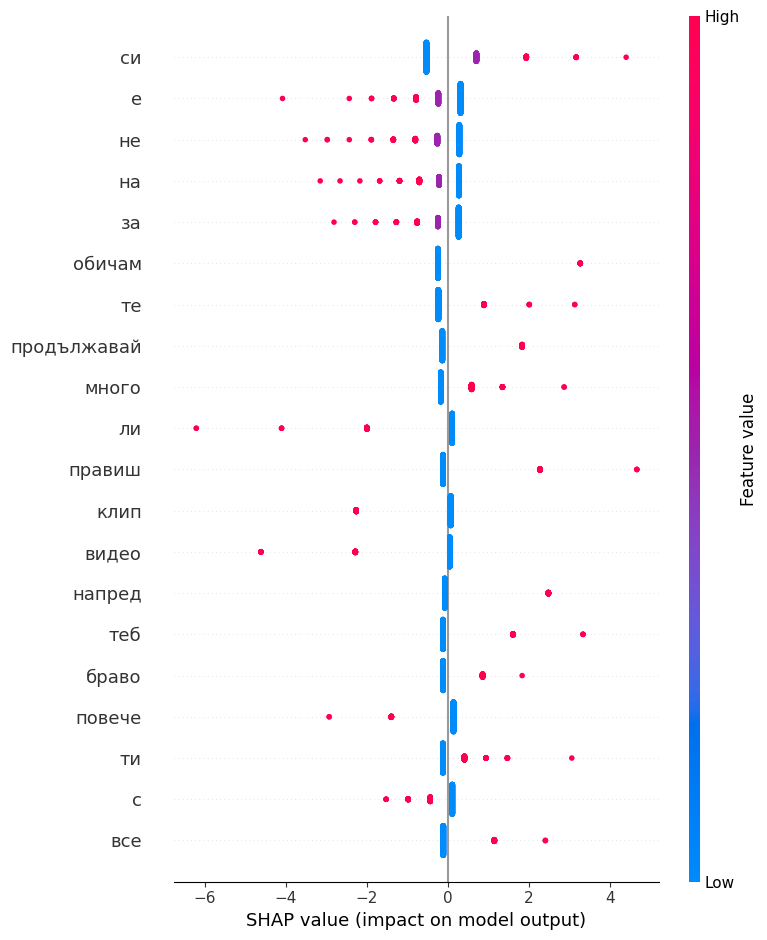

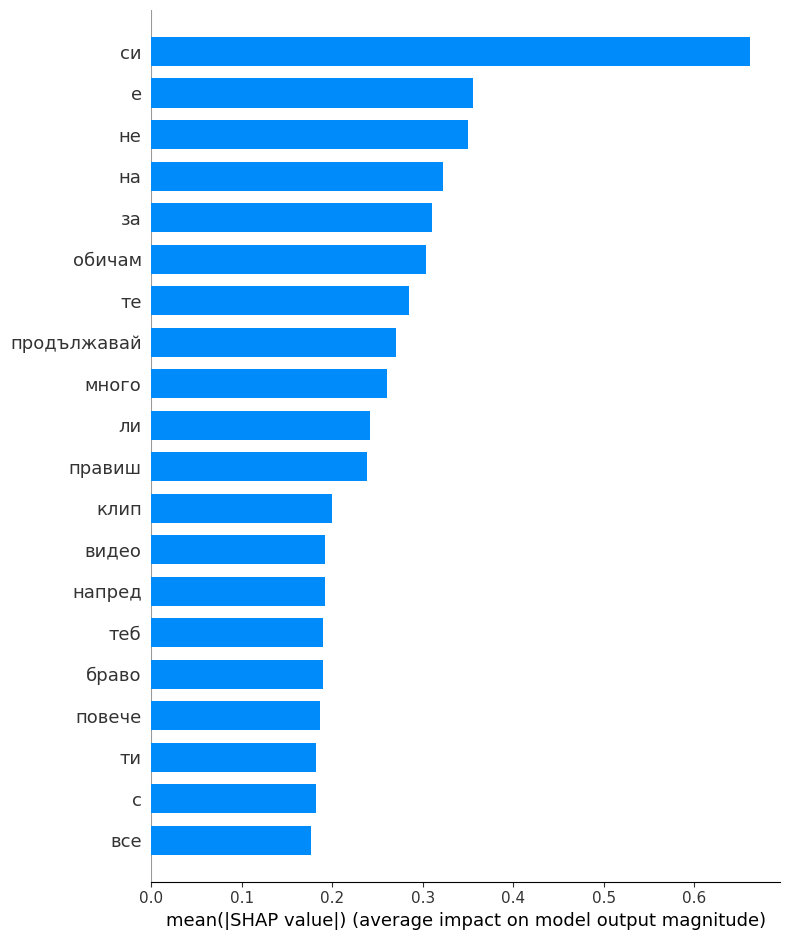

In [ ]:
explainer_logreg_bow, shap_values_logreg_bow = explainable_AI(logreg_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
logreg_model_tfidf.classes_

array([0, 1])

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_logreg_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_logreg_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.7027
Precision: 0.9174
Recall: 0.4454
F1-score: 0.5997
Confusion Matrix:
[[431  18]
 [249 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.96      0.76       449
           1       0.92      0.45      0.60       449

    accuracy                           0.70       898
   macro avg       0.78      0.70      0.68       898
weighted avg       0.78      0.70      0.68       898



Summary plot as a whole:


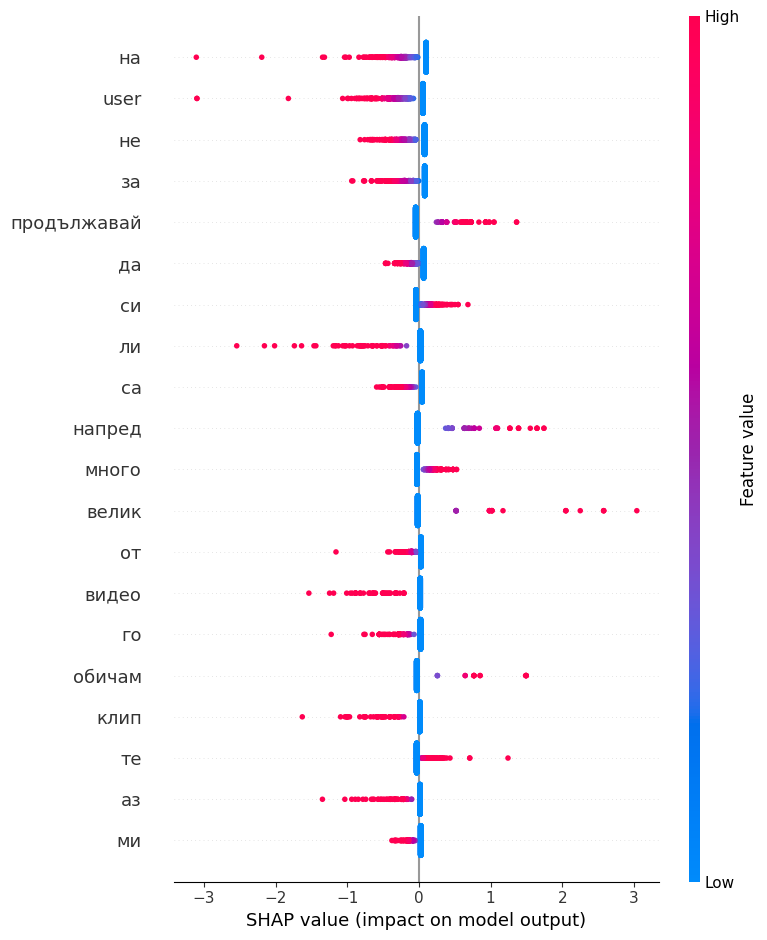

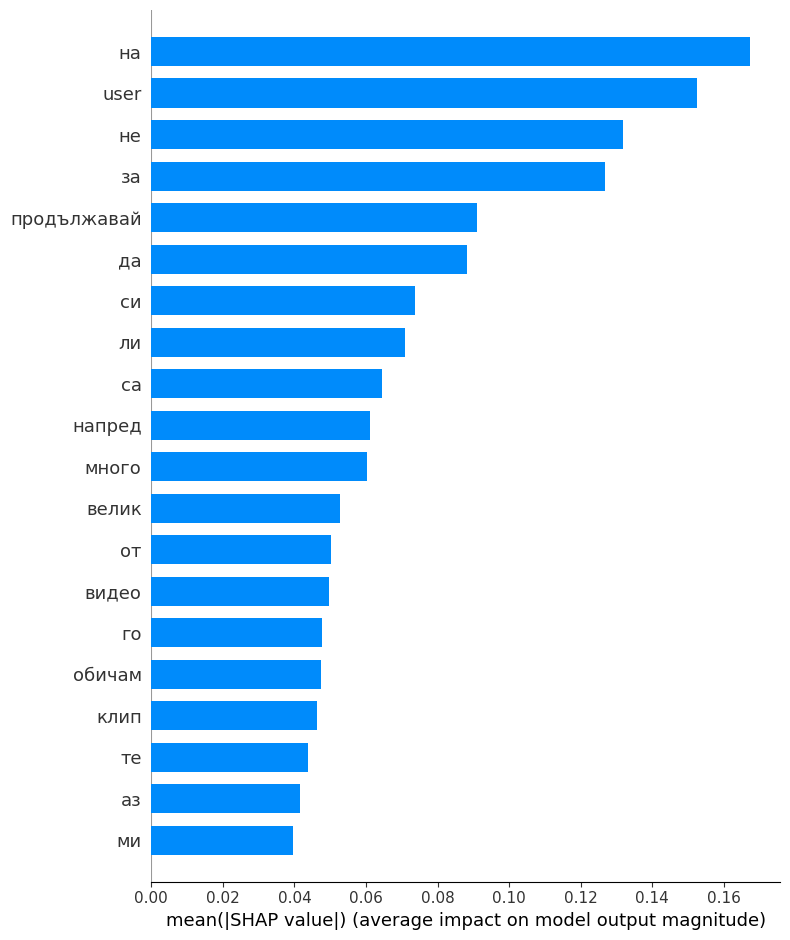

In [ ]:
explainer_logreg_tfidf, shap_values_logreg_tfidf = explainable_AI(logreg_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Linear SVC

In [ ]:
linear_svc_model_bow = LinearSVC(random_state=42)
linear_svc_model_bow.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svc_tfidf = linear_svc_model_bow.predict(X_test_tfidf)

In [ ]:
linear_svc_model_tfidf = LinearSVC(random_state=42)
linear_svc_model_tfidf.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_svc_mybag = linear_svc_model_tfidf.predict(X_test_mybag)

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_svc_tfidf)
y_test_svc_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_svc_tfidf

array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1])

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_svc_mybag)
y_test_svc_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_svc_mybag

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
np.unique(y_test_svc_tfidf)
np.unique(y_test_svc_mybag)

array([False,  True])

In [ ]:
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svc_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svc_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svc_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svc_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svc_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svc_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.7467
Precision: 0.7569
Recall: 0.7267
F1-score: 0.7415
Confusion Matrix:
[[115  35]
 [ 41 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       150
           1       0.76      0.73      0.74       150

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



In [ ]:
explainer_linearsvc_bow, shap_values_linearsvc_bow = explainable_AI(linear_svc_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

ValueError: ignored

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svc_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svc_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svc_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svc_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svc_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svc_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.7333
Precision: 0.7365
Recall: 0.7267
F1-score: 0.7315
Confusion Matrix:
[[111  39]
 [ 41 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       150
           1       0.74      0.73      0.73       150

    accuracy                           0.73       300
   macro avg       0.73      0.73      0.73       300
weighted avg       0.73      0.73      0.73       300



In [ ]:
explainer_svc_tfidf, shap_values_svc_tfidf = explainable_AI(linear_svc_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

ValueError: ignored

# Multinomial Naive Bayes

In [ ]:
# Train Multinomial Naive Bayes model
mnb_model_tfidf = MultinomialNB()
mnb_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_mnb_tfidf = mnb_model_tfidf.predict(X_test_tfidf)

In [ ]:
# Train Multinomial Naive Bayes model
mnb_model_bow = MultinomialNB()
mnb_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_mnb_mybag = mnb_model_bow.predict(X_test_mybag)

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_mnb_tfidf)
y_test_mnb_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_mnb_tfidf

array([1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1])

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_mnb_mybag)
y_test_mnb_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_mnb_mybag

array([0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mnb_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mnb_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mnb_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mnb_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mnb_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mnb_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

TFIDF results:

Accuracy: 0.7900
Precision: 0.8129
Recall: 0.7533
F1-score: 0.7820
Confusion Matrix:
[[124  26]
 [ 37 113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       150
           1       0.81      0.75      0.78       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [ ]:
explainer_mnb_tfidf, shap_values_mnb_tfidf = explainable_AI(mnb_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

TypeError: ignored

In [ ]:
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_mnb_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_mnb_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_mnb_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_mnb_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_mnb_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_mnb_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[124  26]
 [ 37 113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       150
           1       0.81      0.75      0.78       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



In [ ]:
explainer_mnb_bow, shap_values_mnb_bow = explainable_AI(mnb_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

TypeError: ignored

# XG Boost

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert data to DMatrix format used by XGBoost
dtrain = xgb.DMatrix(X_train_mybag, label=y_train)
dtest = xgb.DMatrix(X_test_mybag)

# Set XGBoost parameters (you may adjust these based on your needs)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 50,
    'seed': 42
}

# Train XGBoost model
xgb_model_bow = xgb.train(params, dtrain)

# Predict labels for the test set
y_test_predicted_labels_xgb_mybag = xgb_model_bow.predict(dtest)
y_test_predicted_labels_xgb_mybag = [1 if pred > 0.5 else 0 for pred in y_test_predicted_labels_xgb_mybag]

[05:49:19] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert data to DMatrix format used by XGBoost
dtrain = xgb.DMatrix(X_train_tfidf, label=y_train)
dtest = xgb.DMatrix(X_test_tfidf)

# Set XGBoost parameters (you may adjust these based on your needs)
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 50,
    'seed': 42
}

# Train XGBoost model
xgb_model_tfidf = xgb.train(params, dtrain)

# Predict labels for the test set
y_test_predicted_labels_xgb_tfidf = xgb_model_tfidf.predict(dtest)
y_test_predicted_labels_xgb_tfidf = [1 if pred > 0.5 else 0 for pred in y_test_predicted_labels_xgb_tfidf]

[05:49:40] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "n_estimators" } are not used.



In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_xgb_mybag)
y_test_xgb_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_xgb_mybag

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,


In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_xgb_tfidf)
y_test_xgb_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_xgb_tfidf

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,


In [ ]:
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_xgb_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_xgb_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_xgb_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_xgb_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_xgb_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_xgb_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.6367
Precision: 0.6847
Recall: 0.5067
F1-score: 0.5824
Confusion Matrix:
[[115  35]
 [ 74  76]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.77      0.68       150
           1       0.68      0.51      0.58       150

    accuracy                           0.64       300
   macro avg       0.65      0.64      0.63       300
weighted avg       0.65      0.64      0.63       300



In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_xgb_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_xgb_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_xgb_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_xgb_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_xgb_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_xgb_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.6367
Precision: 0.7030
Recall: 0.4733
F1-score: 0.5657
Confusion Matrix:
[[120  30]
 [ 79  71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.80      0.69       150
           1       0.70      0.47      0.57       150

    accuracy                           0.64       300
   macro avg       0.65      0.64      0.63       300
weighted avg       0.65      0.64      0.63       300



# Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train AdaBoost model
adaboost_model_bow = AdaBoostClassifier(random_state=42)
adaboost_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_adaboost_mybag = adaboost_model_bow.predict(X_test_mybag)

In [ ]:
# Train AdaBoost model
adaboost_model_tfidf = AdaBoostClassifier(random_state=42)
adaboost_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_adaboost_tfidf = adaboost_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_adaboost_mybag)
y_test_adaboost_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_adaboost_mybag

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_adaboost_tfidf)
y_test_adaboost_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_adaboost_tfidf

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_adaboost_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_adaboost_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_adaboost_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_adaboost_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_adaboost_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_adaboost_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words result:

Accuracy: 0.7300
Precision: 0.7556
Recall: 0.6800
F1-score: 0.7158
Confusion Matrix:
[[117  33]
 [ 48 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       150
           1       0.76      0.68      0.72       150

    accuracy                           0.73       300
   macro avg       0.73      0.73      0.73       300
weighted avg       0.73      0.73      0.73       300



In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_adaboost_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_adaboost_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_adaboost_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_adaboost_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_adaboost_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_adaboost_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF results:

Accuracy: 0.7033
Precision: 0.7133
Recall: 0.6800
F1-score: 0.6962
Confusion Matrix:
[[109  41]
 [ 48 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       150
           1       0.71      0.68      0.70       150

    accuracy                           0.70       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.70      0.70      0.70       300



# Decision Tree

In [ ]:
# Train Decision Tree model
decision_tree_model_bow = DecisionTreeClassifier(random_state=42)
decision_tree_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_tree_mybag = decision_tree_model_bow.predict(X_test_mybag)

In [ ]:
# Train Decision Tree model
decision_tree_model_tfidf = DecisionTreeClassifier(random_state=42)
decision_tree_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_tree_tfidf = decision_tree_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_tree_mybag)
y_test_tree_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_tree_mybag

array([0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_tree_tfidf)
y_test_tree_mybag_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_tree_tfidf

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1])

In [ ]:
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tree_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tree_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tree_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tree_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrixx
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tree_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tree_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words results:

Accuracy: 0.7000
Precision: 0.6974
Recall: 0.7067
F1-score: 0.7020
Confusion Matrix:
[[104  46]
 [ 44 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.70       150
           1       0.70      0.71      0.70       150

    accuracy                           0.70       300
   macro avg       0.70      0.70      0.70       300
weighted avg       0.70      0.70      0.70       300



In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_tree_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_tree_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_tree_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_tree_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrixx
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_tree_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_tree_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF results:

Accuracy: 0.7067
Precision: 0.7067
Recall: 0.7067
F1-score: 0.7067
Confusion Matrix:
[[106  44]
 [ 44 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       150
           1       0.71      0.71      0.71       150

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.71      0.71      0.71       300



# Gradient Boosting

In [ ]:
# Train Gradient Boosting model
gradient_boosting_model_bow = GradientBoostingClassifier(random_state=42)
gradient_boosting_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_gb_mybag = gradient_boosting_model_bow.predict(X_test_mybag)

In [ ]:
# Train Gradient Boosting model
gradient_boosting_model_tfidf = GradientBoostingClassifier(random_state=42)
gradient_boosting_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_gb_tfidf = gradient_boosting_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_gb_mybag)
y_test_gb_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_gb_mybag

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_gb_tfidf)
y_test_gb_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_gb_tfidf

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
print(f"Bag of words results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_gb_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_gb_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_gb_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_gb_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_gb_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_gb_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words results:

Accuracy: 0.7300
Precision: 0.7556
Recall: 0.6800
F1-score: 0.7158
Confusion Matrix:
[[117  33]
 [ 48 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       150
           1       0.76      0.68      0.72       150

    accuracy                           0.73       300
   macro avg       0.73      0.73      0.73       300
weighted avg       0.73      0.73      0.73       300



In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_gb_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_gb_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_gb_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_gb_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_gb_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_gb_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.7533
Precision: 0.7879
Recall: 0.6933
F1-score: 0.7376
Confusion Matrix:
[[122  28]
 [ 46 104]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       150
           1       0.79      0.69      0.74       150

    accuracy                           0.75       300
   macro avg       0.76      0.75      0.75       300
weighted avg       0.76      0.75      0.75       300



# SVM

In [ ]:
from sklearn.svm import SVC
svm_model_bow = SVC(random_state=42)
svm_model_bow.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_svm_tfidf = svm_model_bow.predict(X_test_tfidf)

In [ ]:
from sklearn.svm import SVC
svm_model_tfidf = SVC(random_state=42)
svm_model_tfidf.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_svm_mybag = svm_model_tfidf.predict(X_test_mybag)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_svm_mybag)
y_test_svm_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_svm_mybag

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1])

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_svm_tfidf)
y_test_svm_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_svm_tfidf

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
print(f"bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svm_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svm_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svm_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svm_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svm_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svm_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



bag of words result:

Accuracy: 0.7133
Precision: 0.7424
Recall: 0.6533
F1-score: 0.6950
Confusion Matrix:
[[116  34]
 [ 52  98]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       150
           1       0.74      0.65      0.70       150

    accuracy                           0.71       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.72      0.71      0.71       300



In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_svm_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_svm_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_svm_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_svm_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_svm_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_svm_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Confusion Matrix:
[[125  25]
 [ 39 111]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.80       150
           1       0.82      0.74      0.78       150

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300



# Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_bow = RidgeClassifier(random_state=42)
ridge_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_mybag = ridge_classifier_model_bow.predict(X_test_mybag)

In [ ]:
from sklearn.linear_model import RidgeClassifier

# Train Ridge Classifier model
ridge_classifier_model_tfidf = RidgeClassifier(random_state=42)
ridge_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_ridge_tfidf = ridge_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_ridge_mybag)
y_test_ridge_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_ridge_mybag

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_ridge_tfidf)
y_test_ridge_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_ridge_tfidf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.7194
Precision: 0.9053
Recall: 0.4900
F1-score: 0.6358
Confusion Matrix:
[[426  23]
 [229 220]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.95      0.77       449
           1       0.91      0.49      0.64       449

    accuracy                           0.72       898
   macro avg       0.78      0.72      0.70       898
weighted avg       0.78      0.72      0.70       898



Summary plot as a whole:


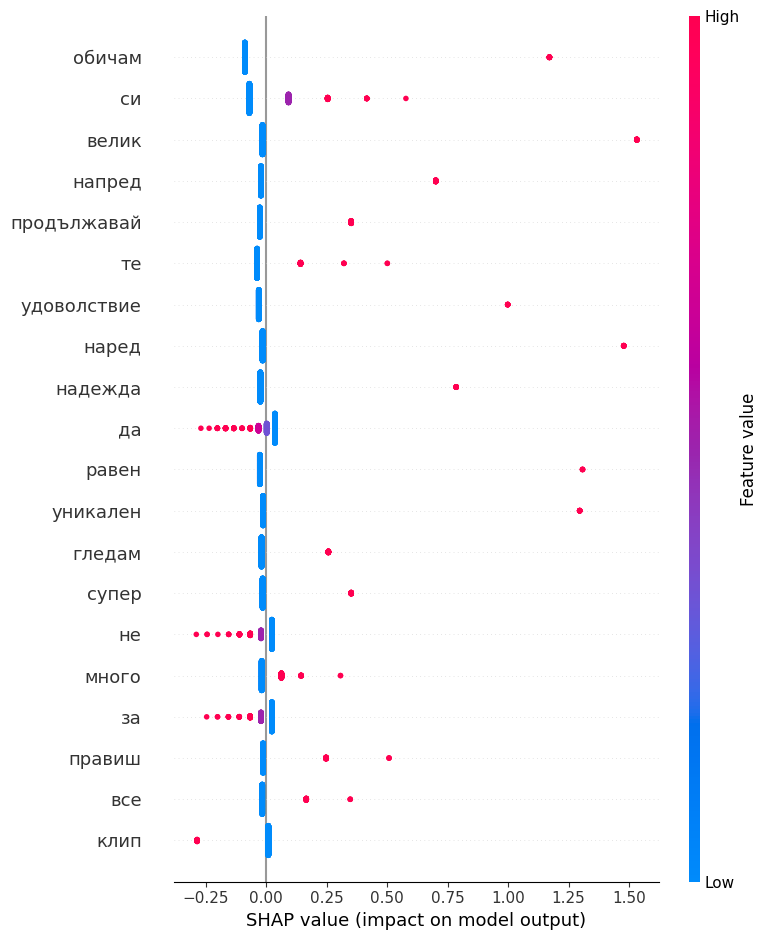

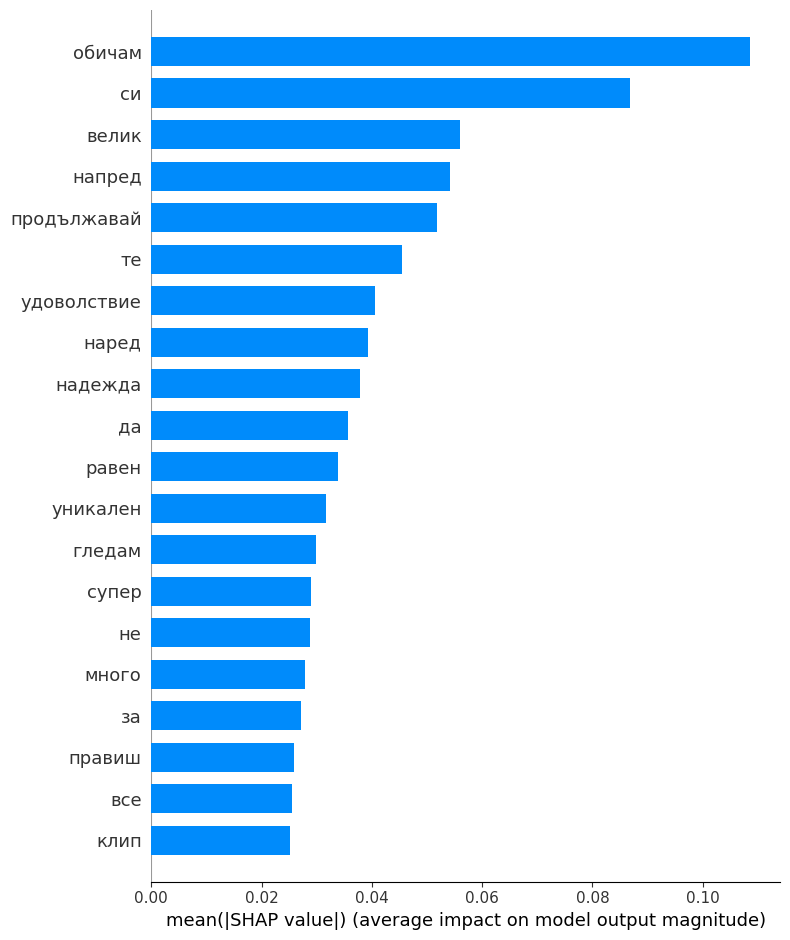

In [ ]:
explainer_ridge_bow, shap_values_ridge_bow = explainable_AI(ridge_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_ridge_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_ridge_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6670
Precision: 0.9518
Recall: 0.3519
F1-score: 0.5138
Confusion Matrix:
[[441   8]
 [291 158]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.98      0.75       449
           1       0.95      0.35      0.51       449

    accuracy                           0.67       898
   macro avg       0.78      0.67      0.63       898
weighted avg       0.78      0.67      0.63       898



Summary plot as a whole:


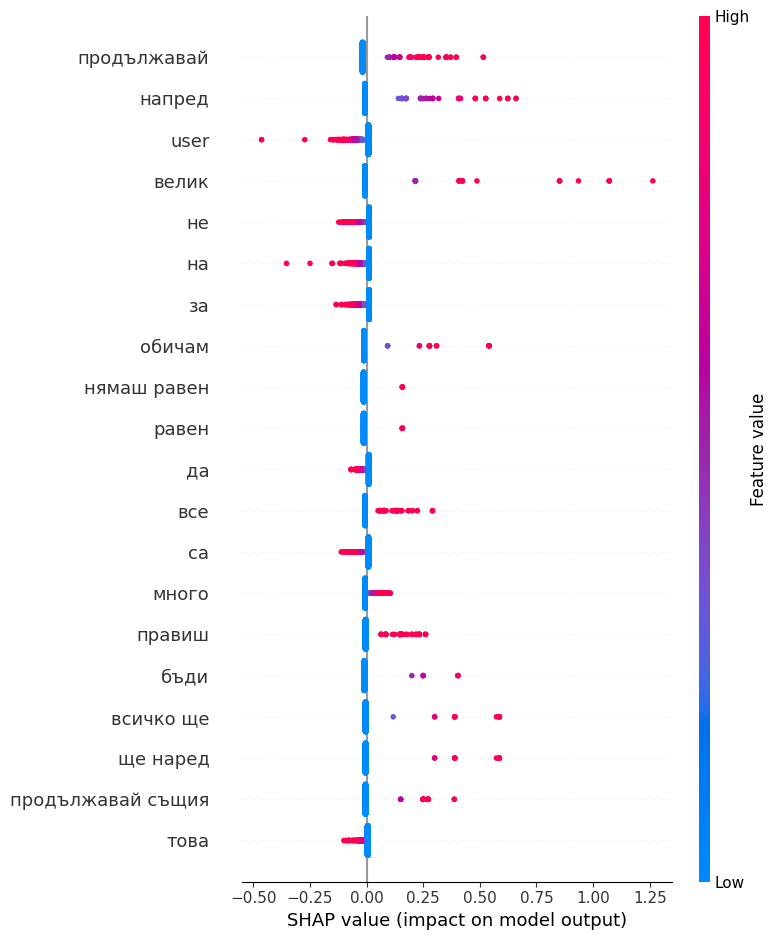

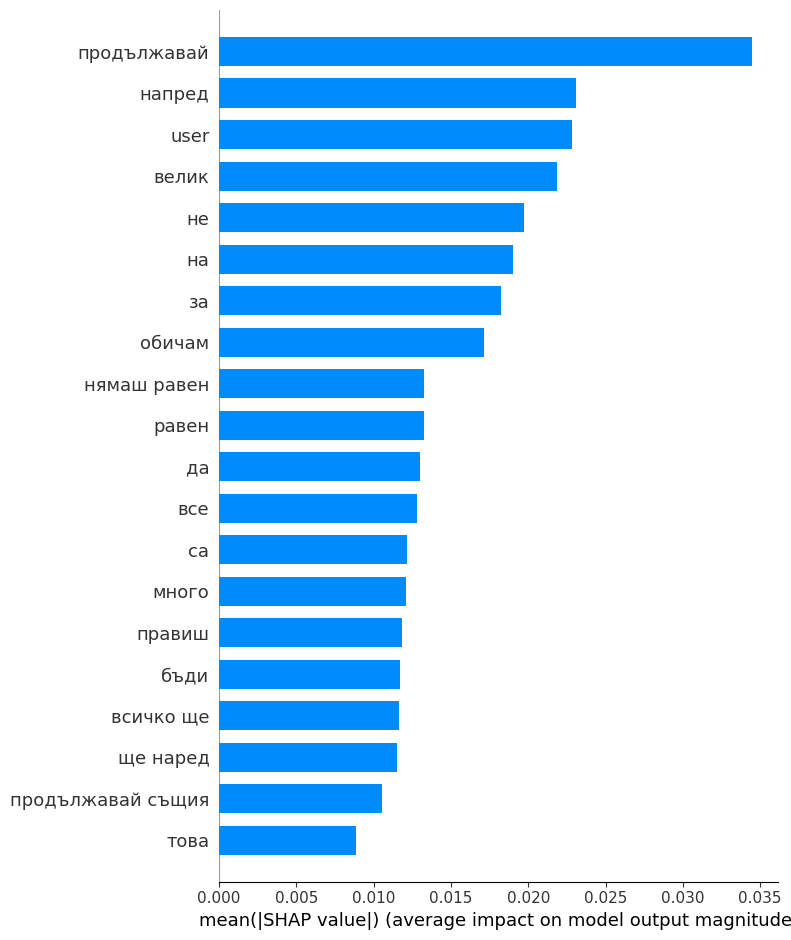

In [ ]:
explainer_ridge_tfidf, shap_values_ridge_tfidf = explainable_AI(ridge_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Perceptron Classifier

In [ ]:
from sklearn.linear_model import Perceptron

# Train Perceptron model
perceptron_model_bow = Perceptron(random_state=42)
perceptron_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_mybag = perceptron_model_bow.predict(X_test_mybag)


In [ ]:
# Train Perceptron model
perceptron_model_tfidf = Perceptron(random_state=42)
perceptron_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_perceptron_tfidf = perceptron_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_perceptron_mybag)
y_test_perceptron_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_perceptron_mybag

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_perceptron_tfidf)
y_test_perceptron_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_perceptron_tfidf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6804
Precision: 0.9219
Recall: 0.3942
F1-score: 0.5523
Confusion Matrix:
[[434  15]
 [272 177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.97      0.75       449
           1       0.92      0.39      0.55       449

    accuracy                           0.68       898
   macro avg       0.77      0.68      0.65       898
weighted avg       0.77      0.68      0.65       898



Summary plot as a whole:


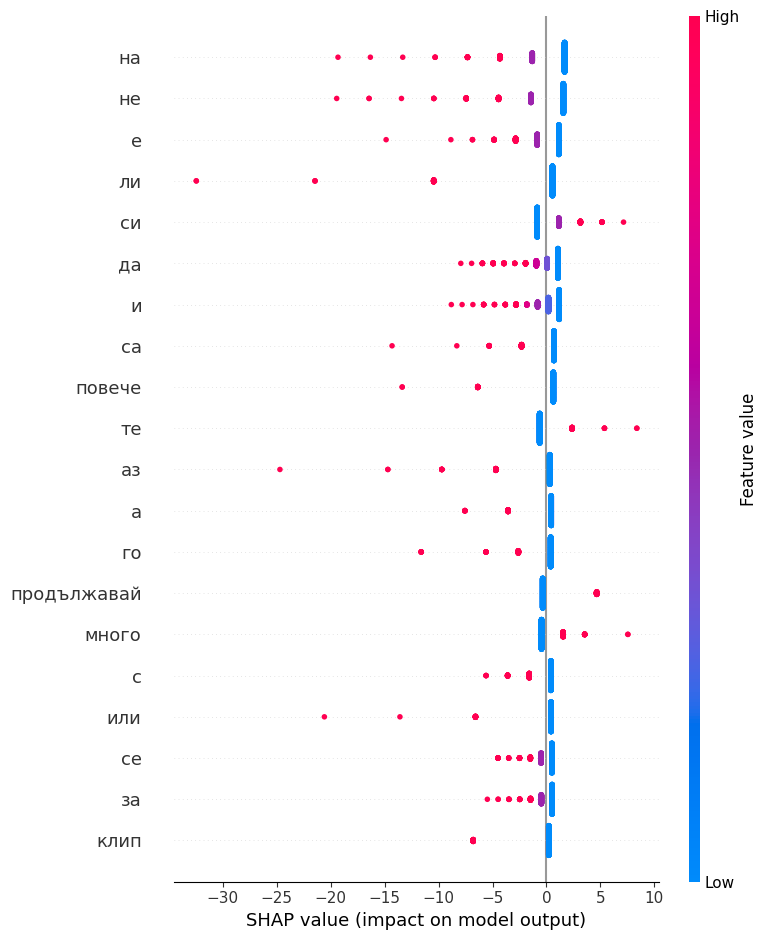

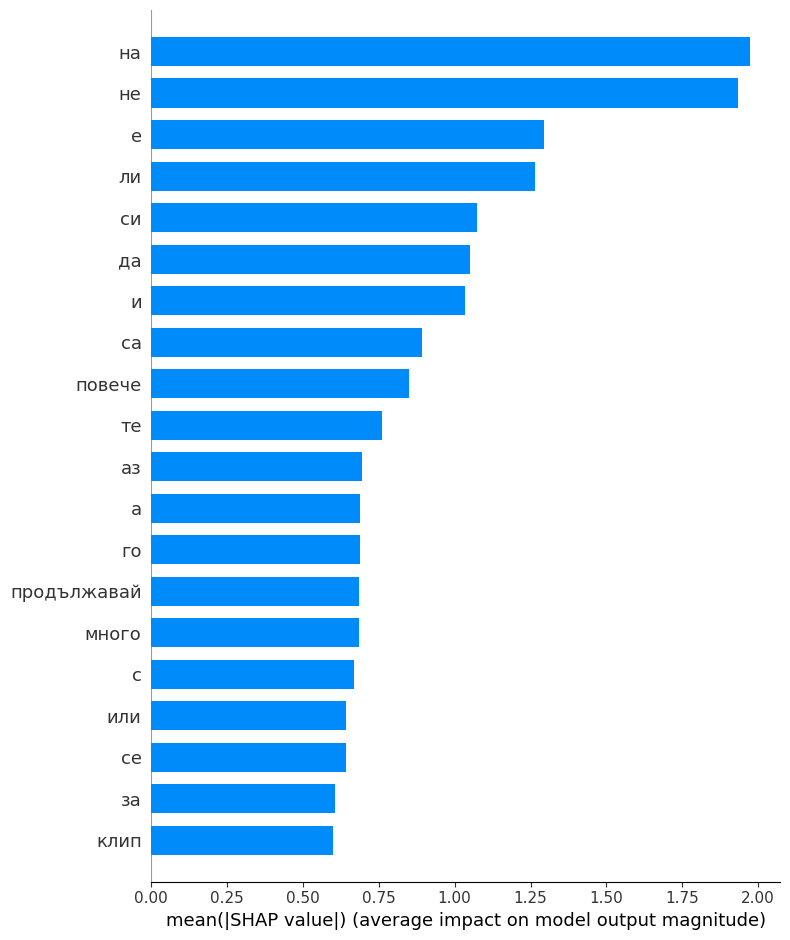

In [ ]:
explainer_perceptron_bow, shap_values_perceptron_bow = explainable_AI(perceptron_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF results:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_perceptron_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_perceptron_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF results:

Accuracy: 0.5835
Precision: 0.9121
Recall: 0.1849
F1-score: 0.3074
Confusion Matrix:
[[441   8]
 [366  83]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.98      0.70       449
           1       0.91      0.18      0.31       449

    accuracy                           0.58       898
   macro avg       0.73      0.58      0.50       898
weighted avg       0.73      0.58      0.50       898



Summary plot as a whole:


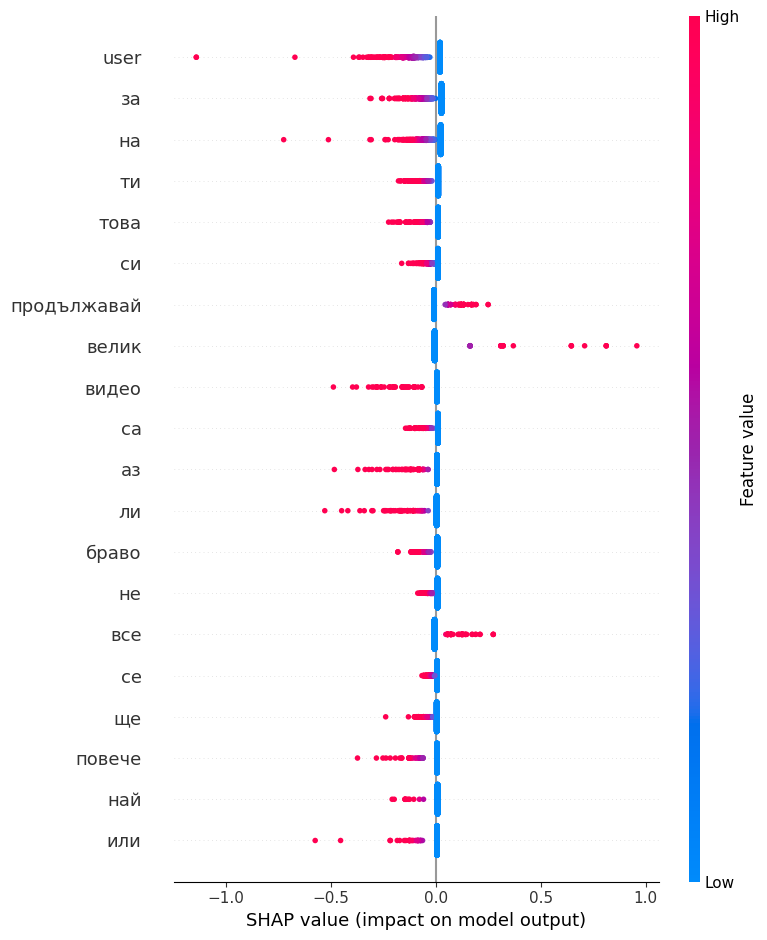

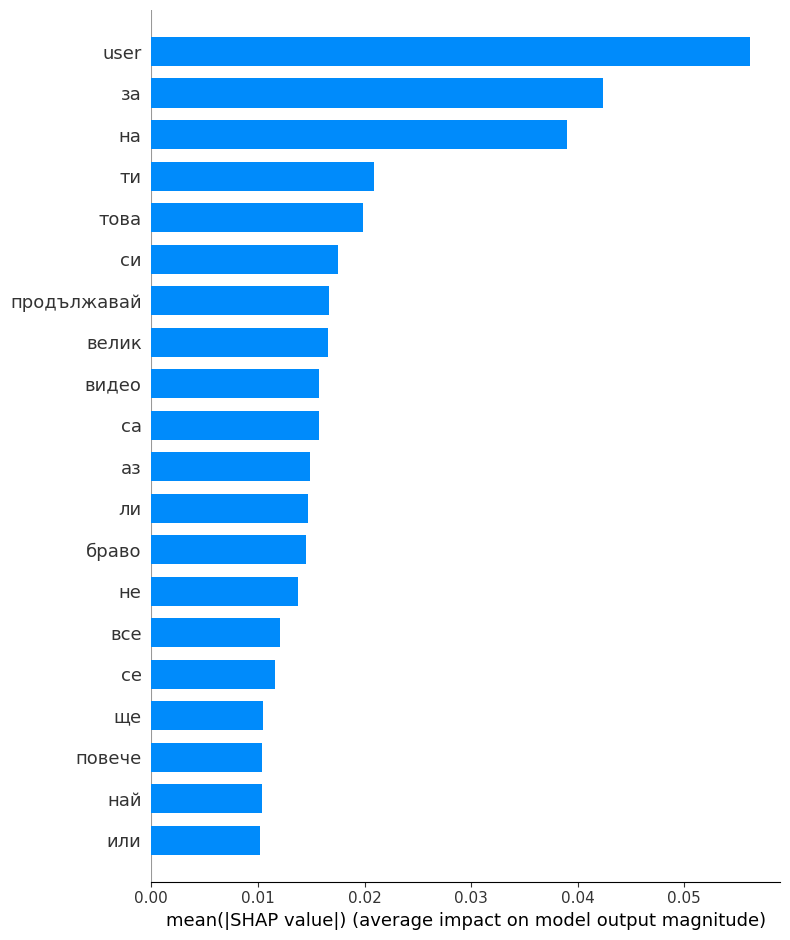

In [ ]:
explainer_perceptron_tfidf, shap_values_perceptron_tfidf = explainable_AI(perceptron_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# SGD classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

# Train SGD Classifier model
sgd_classifier_model_bow = SGDClassifier(random_state=42)
sgd_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_mybag = sgd_classifier_model_bow.predict(X_test_mybag)


In [ ]:
# Train SGD Classifier model
sgd_classifier_model_tfidf = SGDClassifier(random_state=42)
sgd_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_sgd_tfidf = sgd_classifier_model_tfidf.predict(X_test_tfidf)


In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_sgd_mybag)
y_test_sgd_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_sgd_mybag

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_sgd_tfidf)
y_test_sgd_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_sgd_tfidf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Bag of words result:

Accuracy: 0.6993
Precision: 0.9242
Recall: 0.4343
F1-score: 0.5909
Confusion Matrix:
[[433  16]
 [254 195]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.96      0.76       449
           1       0.92      0.43      0.59       449

    accuracy                           0.70       898
   macro avg       0.78      0.70      0.68       898
weighted avg       0.78      0.70      0.68       898



Summary plot as a whole:


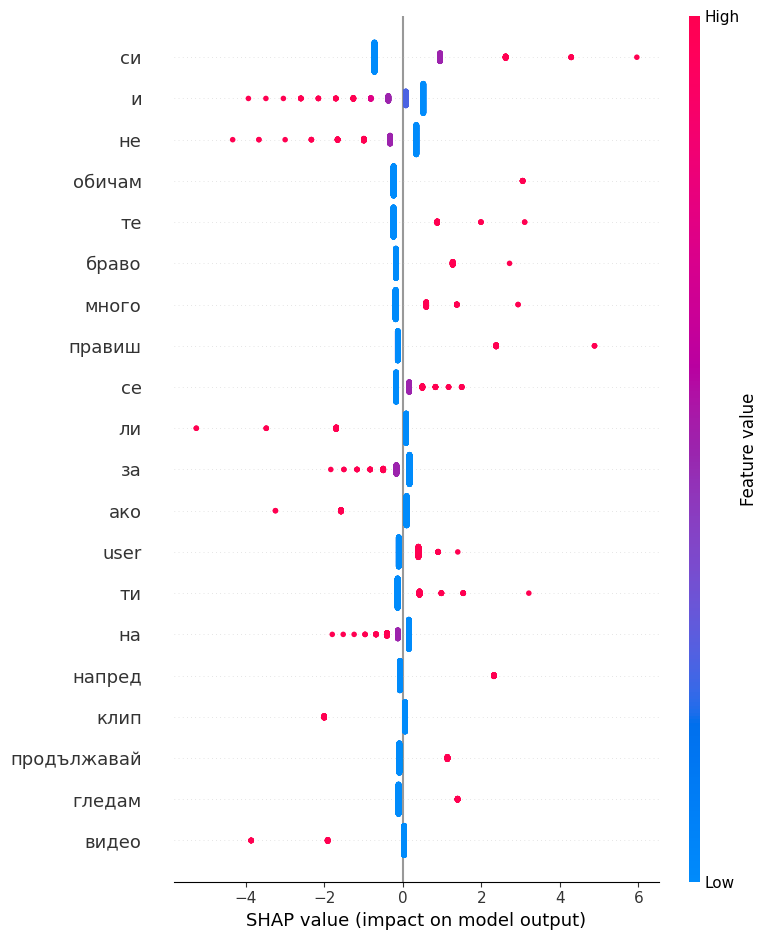

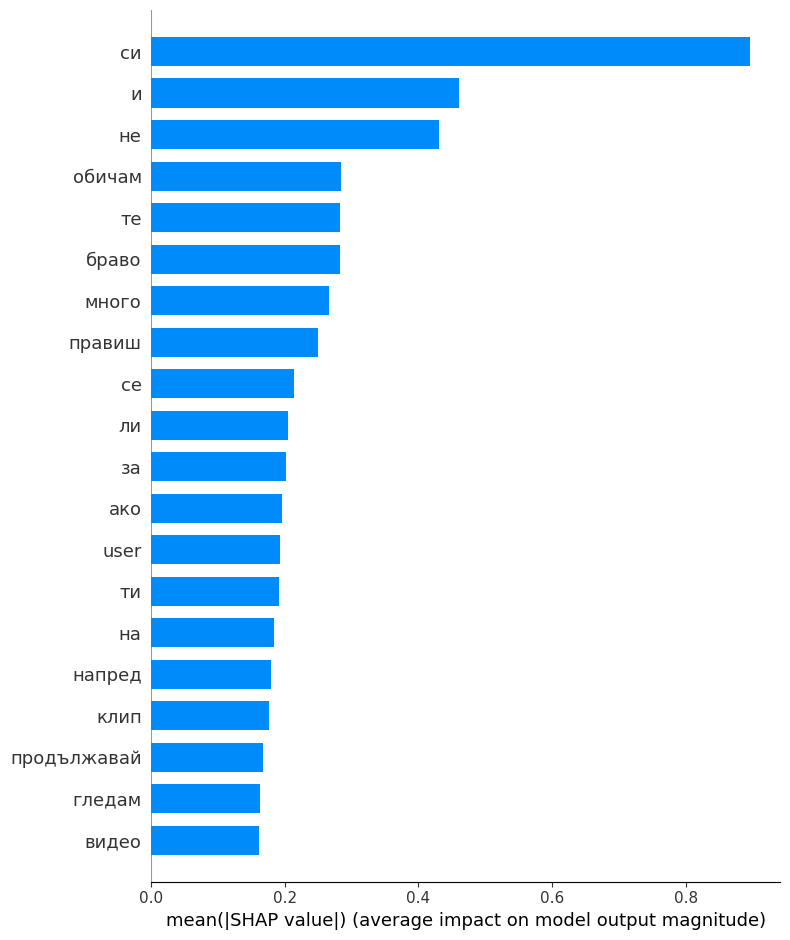

In [ ]:
explainer_sgd_bow, shap_values_sgd_bow = explainable_AI(sgd_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_sgd_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_sgd_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


TFIDF result:

Accuracy: 0.6503
Precision: 0.9592
Recall: 0.3140
F1-score: 0.4732
Confusion Matrix:
[[443   6]
 [308 141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.99      0.74       449
           1       0.96      0.31      0.47       449

    accuracy                           0.65       898
   macro avg       0.77      0.65      0.61       898
weighted avg       0.77      0.65      0.61       898



Summary plot as a whole:


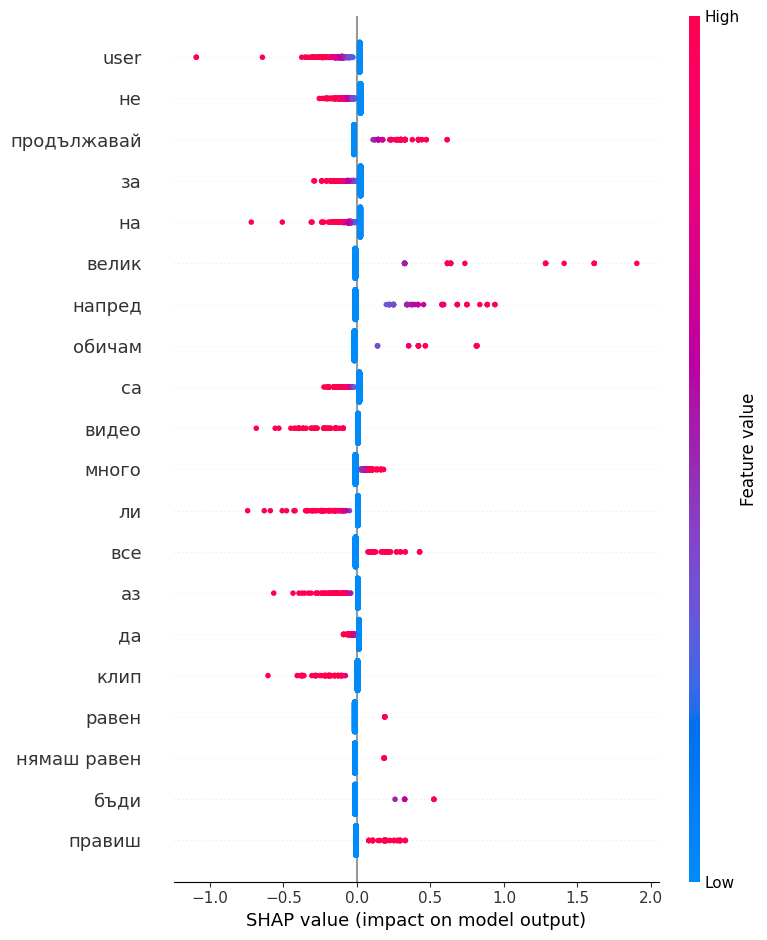

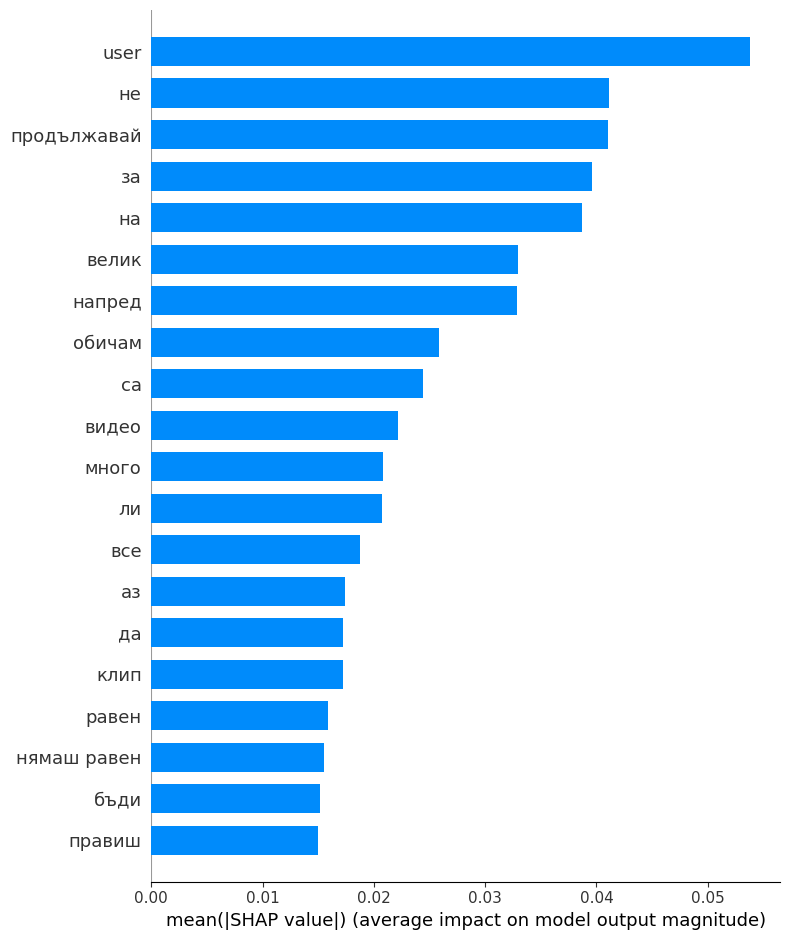

In [ ]:
explainer_sgd_tfidf, shap_values_sgd_tfidf = explainable_AI(sgd_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Passive Aggressive Classifier

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Train Passive Aggressive Classifier model
pa_classifier_model_bow = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_bow.fit(X_train_mybag, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_mybag = pa_classifier_model_bow.predict(X_test_mybag)

In [ ]:
# Train Passive Aggressive Classifier model
pa_classifier_model_tfidf = PassiveAggressiveClassifier(random_state=42)
pa_classifier_model_tfidf.fit(X_train_tfidf, y_train)

# Predict labels for the test set
y_test_predicted_labels_pa_tfidf = pa_classifier_model_tfidf.predict(X_test_tfidf)

In [ ]:
decoded_y_test_mybag= encoder.inverse_transform(y_test_predicted_labels_pa_mybag)
y_test_pa_mybag = [label for label in decoded_y_test_mybag]
y_test_predicted_labels_pa_mybag

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
decoded_y_test_tfidf= encoder.inverse_transform(y_test_predicted_labels_pa_tfidf)
y_test_pa_tfidf = [label for label in decoded_y_test_tfidf]
y_test_predicted_labels_pa_tfidf

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print(f"Bag of words result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_mybag, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_mybag)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



Bag of words result:

Accuracy: 0.6592
Precision: 0.9181
Recall: 0.3497
F1-score: 0.5065
Confusion Matrix:
[[435  14]
 [292 157]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.97      0.74       449
           1       0.92      0.35      0.51       449

    accuracy                           0.66       898
   macro avg       0.76      0.66      0.62       898
weighted avg       0.76      0.66      0.62       898



Summary plot as a whole:


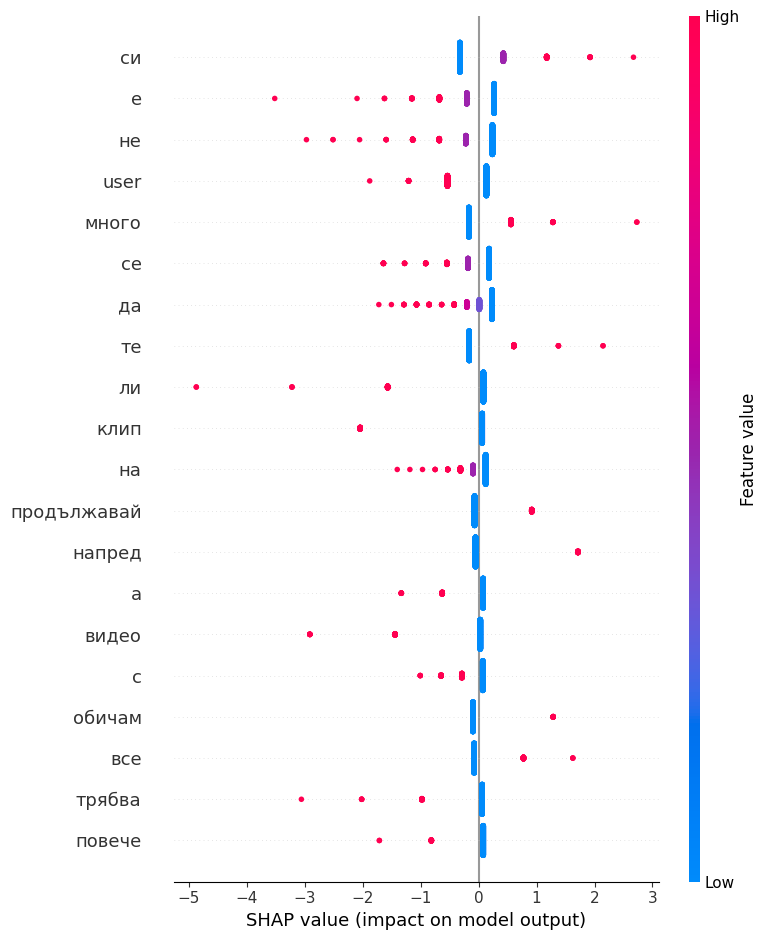

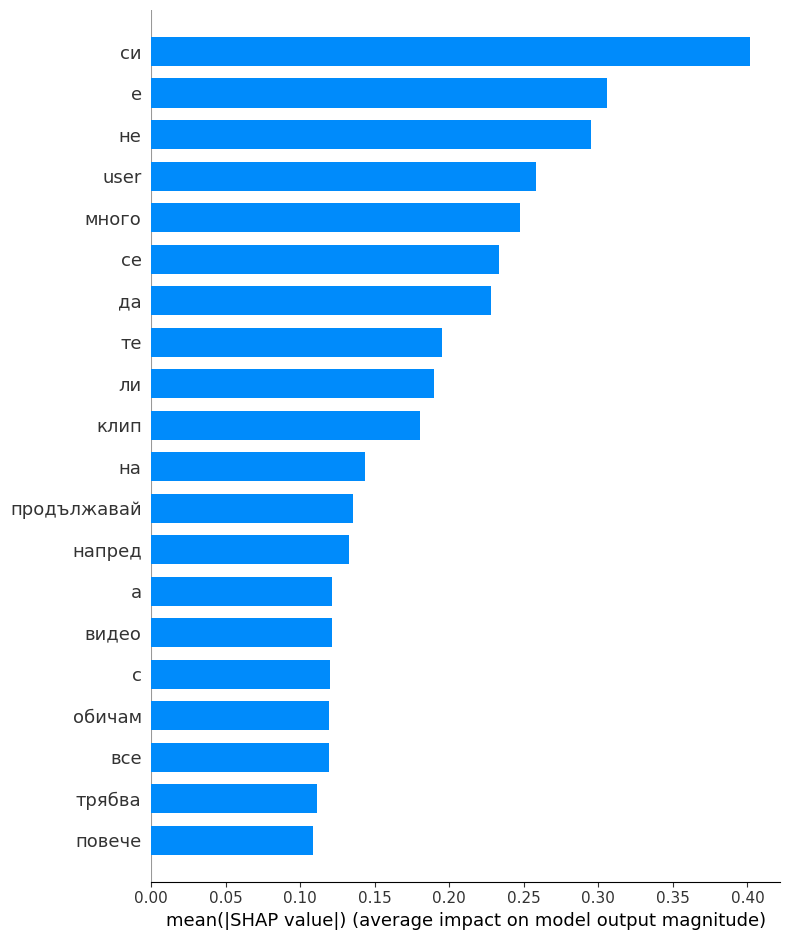

In [ ]:
explainer_pa_bow, shap_values_pa_bow = explainable_AI(pa_classifier_model_bow,X_train_mybag,list(ALL_WORDS),X_test_mybag,shap.Explainer,False)

In [ ]:
print(f"TFIDF result:\n")
# Calculate accuracy
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate precision
precision = precision_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate recall
recall = recall_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Calculate F1-score
f1 = f1_score(y_true_numeric, y_test_predicted_labels_pa_tfidf, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_pa_tfidf)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")



TFIDF result:

Accuracy: 0.5791
Precision: 0.9080
Recall: 0.1759
F1-score: 0.2948
Confusion Matrix:
[[441   8]
 [370  79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.98      0.70       449
           1       0.91      0.18      0.29       449

    accuracy                           0.58       898
   macro avg       0.73      0.58      0.50       898
weighted avg       0.73      0.58      0.50       898



Summary plot as a whole:


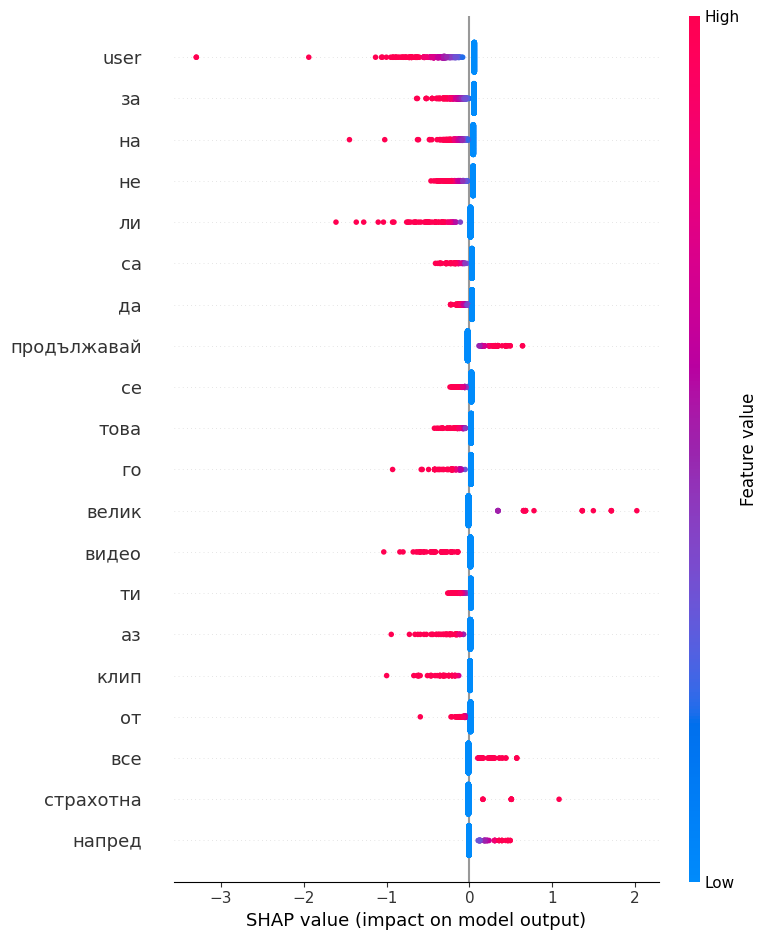

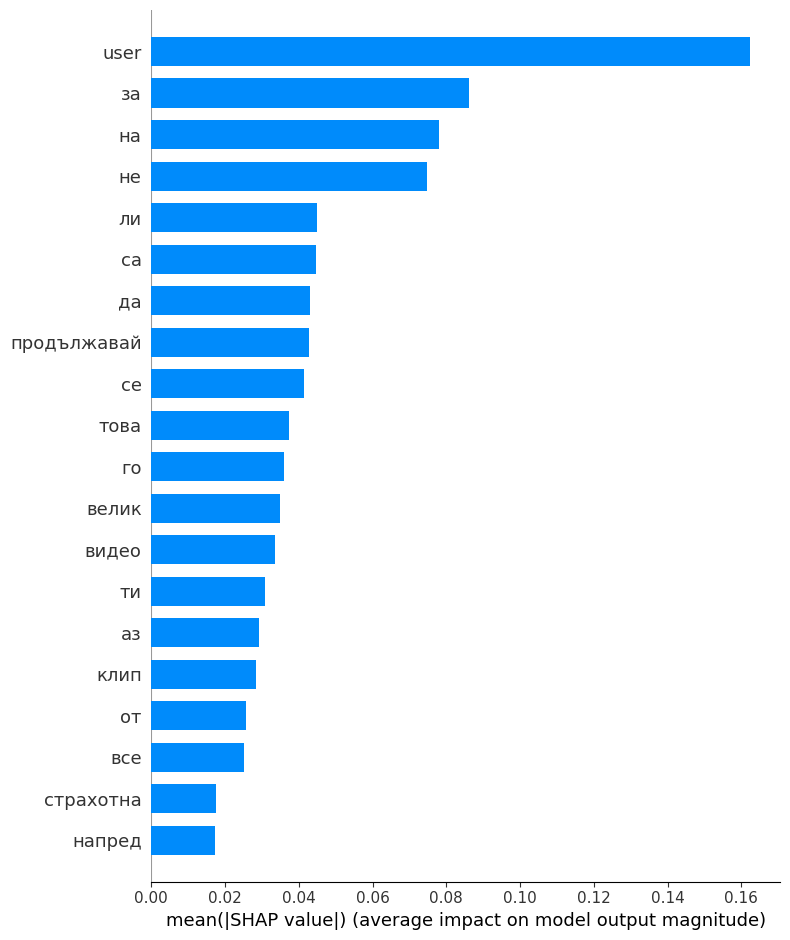

In [ ]:
explainer_pa_tfidf, shap_values_pa_tfidf = explainable_AI(pa_classifier_model_tfidf,X_train_tfidf,feature_names_tfidf,X_test_tfidf,shap.Explainer)

# Deep Learning Models

# CNN

In [ ]:
pip install tensorflow

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Assuming df_test_labels contains the true labels for the test set
# df_test_labels = pd.read_csv("/content/english/Hope_eng_test_with_labels.csv", index_col=0)
# y_true = df_test_labels['Labels']

# Tokenize and pad sequences
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Create a LabelEncoder and fit on the true labels
encoder = LabelEncoder()
encoder_2 = LabelEncoder()
y_train_encoded = encoder_2.fit_transform(y_train)
encoder.fit(y_true)

# Build CNN model
model = Sequential()
model.add(Embedding(max_words, 50, input_length=max_len))
model.add(Conv1D(128, 5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, validation_split=0.2)

# Convert true labels to numeric values
y_true_numeric = encoder.transform(y_true)

# Predict on the test set
y_test_probabilities = model.predict(X_test_pad)
y_test_predicted_labels_cnn = (y_test_probabilities > 0.5).astype(int)

# Convert predicted labels back to original labels
y_test_predicted_labels_cnn_str = encoder.inverse_transform(y_test_predicted_labels_cnn.flatten())

# Evaluate the model
accuracy_cnn = accuracy_score(y_true_numeric, y_test_predicted_labels_cnn)
precision_cnn = precision_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
recall_cnn = recall_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)
f1_cnn = f1_score(y_true_numeric, y_test_predicted_labels_cnn, average='weighted', zero_division=0)

# Print the results
print(f"Accuracy: {accuracy_cnn:.4f}")
print(f"Precision: {precision_cnn:.4f}")
print(f"Recall: {recall_cnn:.4f}")
print(f"F1-score: {f1_cnn:.4f}")


Epoch 1/10
15/15 [==============================] - 22s 628ms/step - loss: 0.6685 - accuracy: 0.6282 - val_loss: 1.0604 - val_accuracy: 0.0000e+00
Epoch 2/10
15/15 [==============================] - 5s 352ms/step - loss: 0.6451 - accuracy: 0.6261 - val_loss: 0.9883 - val_accuracy: 0.0000e+00
Epoch 3/10
15/15 [==============================] - 5s 385ms/step - loss: 0.5940 - accuracy: 0.6261 - val_loss: 1.0054 - val_accuracy: 0.0000e+00
Epoch 4/10
15/15 [==============================] - 4s 249ms/step - loss: 0.4412 - accuracy: 0.7710 - val_loss: 0.9776 - val_accuracy: 0.2667
Epoch 5/10
15/15 [==============================] - 2s 107ms/step - loss: 0.2182 - accuracy: 0.9685 - val_loss: 0.7672 - val_accuracy: 0.6250
Epoch 6/10
15/15 [==============================] - 2s 132ms/step - loss: 0.0482 - accuracy: 0.9958 - val_loss: 0.3825 - val_accuracy: 0.8250
Epoch 7/10
15/15 [==============================] - 1s 86ms/step - loss: 0.0101 - accuracy: 1.0000 - val_loss: 1.2932 - val_accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels_cnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels_cnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[125  25]
 [ 48 102]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       150
           1       0.80      0.68      0.74       150

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300



PermutationExplainer explainer: 301it [26:59,  5.42s/it]


Summary plot as a whole:


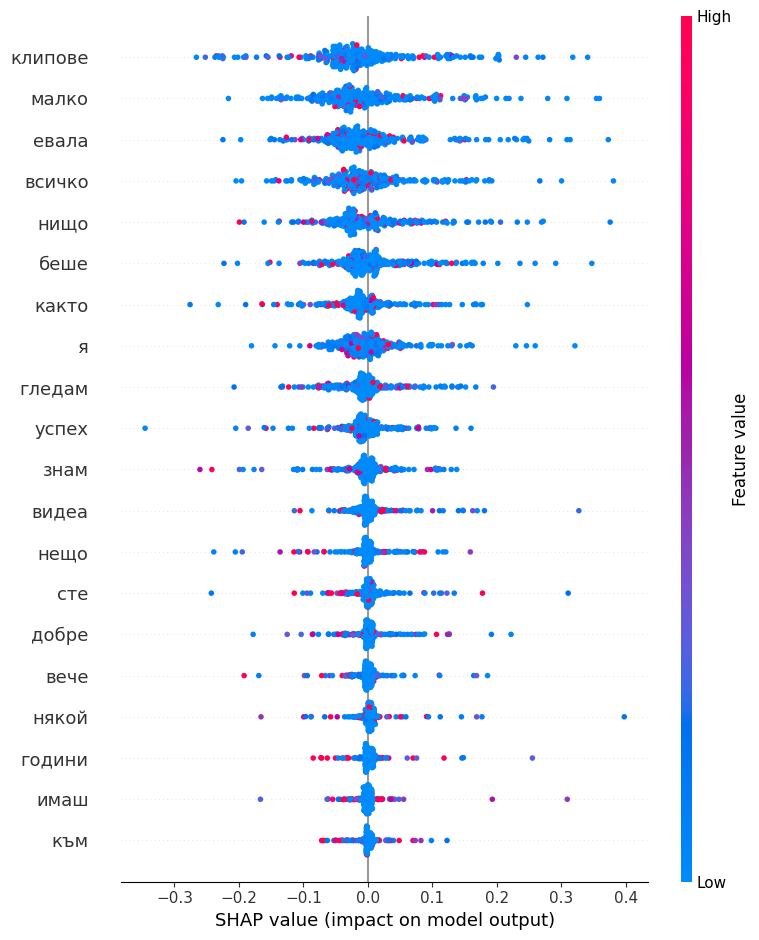

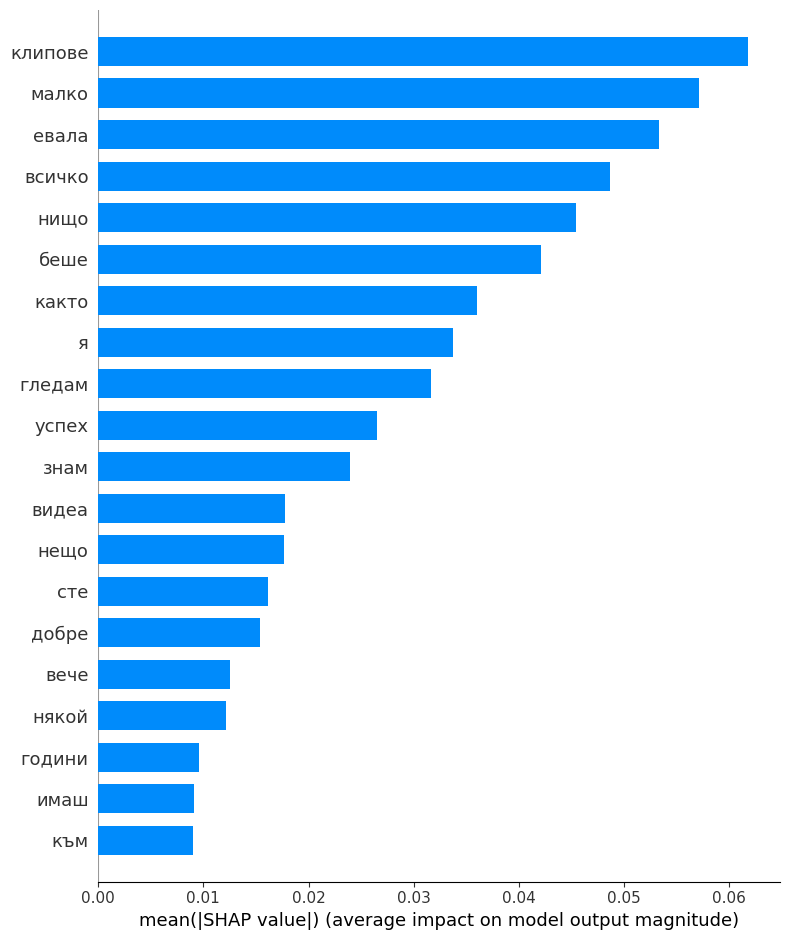

In [ ]:
explainer_cnn, shap_values_cnn = explainable_AI(model,X_train_pad,list(ALL_WORDS),X_test_pad,shap.Explainer,False)

# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, return_sequences=True))  # Add return_sequences=True for stacking LSTM layers
# model.add(Dropout(0.2))  # Dropout for regularization
model.add(LSTM(100))
# model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob = model.predict(X_test_seq)
y_test_pred = (y_test_prob > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_lstm = accuracy_score(y_true_numeric, y_test_pred)
precision_lstm = precision_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
recall_lstm = recall_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)
f1_lstm = f1_score(y_true_numeric, y_test_pred, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Precision: {precision_lstm:.4f}")
print(f"Recall: {recall_lstm:.4f}")
print(f"F1 Score: {f1_lstm:.4f}")


Epoch 1/10
15/15 [==============================] - 9s 309ms/step - loss: 0.6722 - accuracy: 0.6239 - val_loss: 0.8222 - val_accuracy: 0.0000e+00
Epoch 2/10
15/15 [==============================] - 3s 201ms/step - loss: 0.6477 - accuracy: 0.6261 - val_loss: 1.1621 - val_accuracy: 0.0000e+00
Epoch 3/10
15/15 [==============================] - 3s 194ms/step - loss: 0.5290 - accuracy: 0.6849 - val_loss: 2.3508 - val_accuracy: 0.0833
Epoch 4/10
15/15 [==============================] - 4s 262ms/step - loss: 0.3429 - accuracy: 0.8824 - val_loss: 0.8853 - val_accuracy: 0.5333
Epoch 5/10
15/15 [==============================] - 3s 202ms/step - loss: 0.1237 - accuracy: 0.9538 - val_loss: 1.2309 - val_accuracy: 0.6000
Epoch 6/10
15/15 [==============================] - 3s 204ms/step - loss: 0.0516 - accuracy: 0.9853 - val_loss: 1.0581 - val_accuracy: 0.7083
Epoch 7/10
15/15 [==============================] - 3s 203ms/step - loss: 0.0286 - accuracy: 0.9916 - val_loss: 0.7799 - val_accuracy: 0.775

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix.
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[119  31]
 [ 47 103]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75       150
           1       0.77      0.69      0.73       150

    accuracy                           0.74       300
   macro avg       0.74      0.74      0.74       300
weighted avg       0.74      0.74      0.74       300



In [ ]:
explainer_lstm, shap_values_lstm = explainable_AI(model,X_train_seq,list(ALL_WORDS),X_test_seq,shap.Explainer,False)

PermutationExplainer explainer:  17%|█▋        | 52/300 [29:58<2:31:26, 36.64s/it]

# Bi-LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad sequences
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Define the bi-LSTM model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
# model.add(SpatialDropout1D(0.2))
model.add(Bidirectional(LSTM(100)))
model.add(Dense(64, activation='relu'))  # Additional dense layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
y_test_prob_bilstm = model.predict(X_test_seq)
y_test_pred_bilstm = (y_test_prob_bilstm > 0.5).astype(int)

# Convert y_true to numeric values
y_true_numeric = encoder.transform(y_true)

# Evaluate the model
accuracy_bilstm = accuracy_score(y_true_numeric, y_test_pred_bilstm)
precision_bilstm = precision_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
recall_bilstm = recall_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)
f1_bilstm = f1_score(y_true_numeric, y_test_pred_bilstm, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy_bilstm:.4f}")
print(f"Precision: {precision_bilstm:.4f}")
print(f"Recall: {recall_bilstm:.4f}")
print(f"F1 Score: {f1_bilstm:.4f}")


Epoch 1/10
249/249 [==============================] - 42s 157ms/step - loss: 0.2482 - accuracy: 0.8912 - val_loss: 0.0499 - val_accuracy: 0.9889
Epoch 2/10
249/249 [==============================] - 38s 151ms/step - loss: 0.0267 - accuracy: 0.9933 - val_loss: 0.0184 - val_accuracy: 0.9940
Epoch 3/10
249/249 [==============================] - 37s 149ms/step - loss: 0.0104 - accuracy: 0.9979 - val_loss: 0.0020 - val_accuracy: 1.0000
Epoch 4/10
249/249 [==============================] - 37s 148ms/step - loss: 0.0066 - accuracy: 0.9976 - val_loss: 0.0220 - val_accuracy: 0.9909
Epoch 5/10
249/249 [==============================] - 37s 150ms/step - loss: 0.0076 - accuracy: 0.9975 - val_loss: 0.0041 - val_accuracy: 1.0000
Epoch 6/10
249/249 [==============================] - 38s 151ms/step - loss: 0.0025 - accuracy: 0.9994 - val_loss: 7.5277e-04 - val_accuracy: 1.0000
Epoch 7/10
249/249 [==============================] - 36s 145ms/step - loss: 0.0021 - accuracy: 0.9995 - val_loss: 3.6012e-04 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_pred_bilstm)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_pred_bilstm)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[436  13]
 [324 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.97      0.72       449
           1       0.91      0.28      0.43       449

    accuracy                           0.62       898
   macro avg       0.74      0.62      0.57       898
weighted avg       0.74      0.62      0.57       898



# DNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn)
precision = precision_score(y_true_numeric, y_pred_dnn, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
8/8 [==============================] - 4s 176ms/step - loss: 0.6728 - accuracy: 0.6134 - val_loss: 0.7460 - val_accuracy: 0.0083
Epoch 2/10
8/8 [==============================] - 1s 120ms/step - loss: 0.6679 - accuracy: 0.6071 - val_loss: 0.9018 - val_accuracy: 0.0000e+00
Epoch 3/10
8/8 [==============================] - 1s 128ms/step - loss: 0.6712 - accuracy: 0.6366 - val_loss: 0.7676 - val_accuracy: 0.0000e+00
Epoch 4/10
8/8 [==============================] - 1s 91ms/step - loss: 0.6576 - accuracy: 0.6218 - val_loss: 0.9949 - val_accuracy: 0.0000e+00
Epoch 5/10
8/8 [==============================] - 1s 93ms/step - loss: 0.6510 - accuracy: 0.6324 - val_loss: 0.8714 - val_accuracy: 0.0000e+00
Epoch 6/10
8/8 [==============================] - 1s 104ms/step - loss: 0.6101 - accuracy: 0.6492 - val_loss: 0.9774 - val_accuracy: 0.0000e+00
Epoch 7/10
8/8 [==============================] - 1s 170ms/step - loss: 0.5337 - accuracy: 0.6807 - val_loss: 1.1405 - val_accuracy: 0.0083
Ep

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[131  19]
 [ 87  63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.87      0.71       150
           1       0.77      0.42      0.54       150

    accuracy                           0.65       300
   macro avg       0.68      0.65      0.63       300
weighted avg       0.68      0.65      0.63       300



PermutationExplainer explainer: 301it [00:25,  7.16it/s]


Summary plot as a whole:


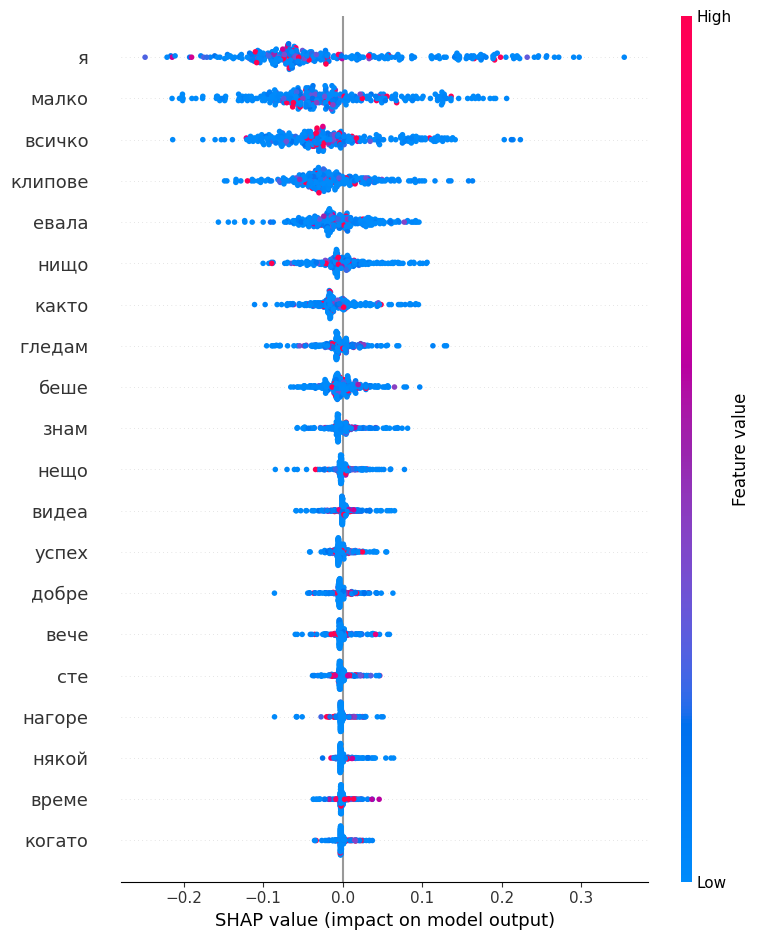

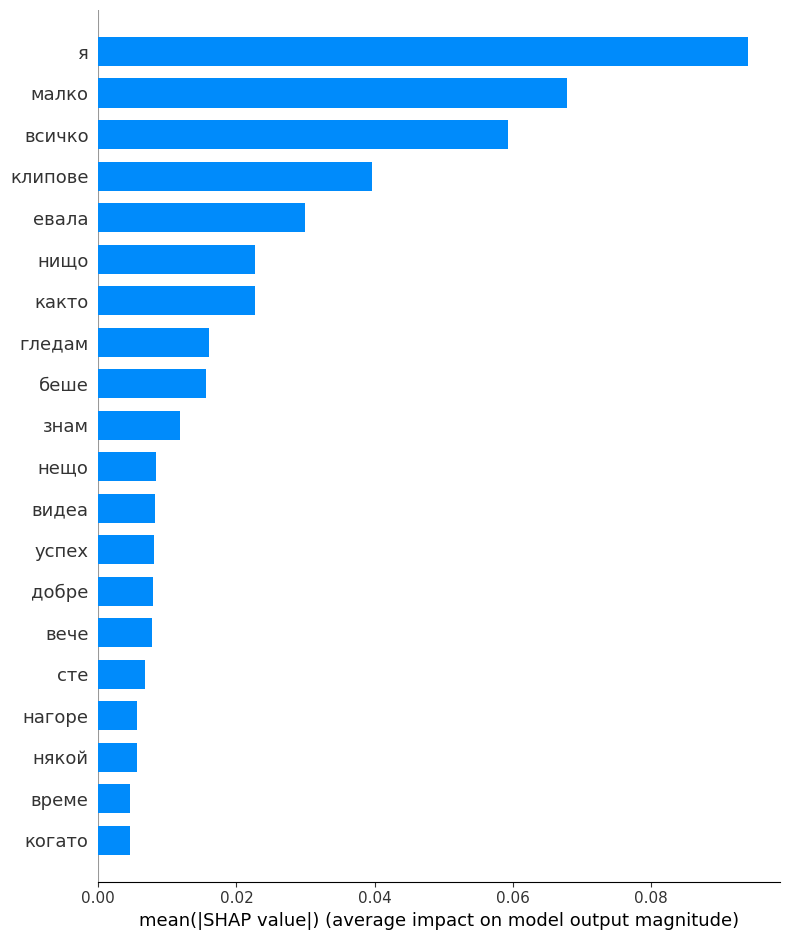

In [ ]:
explainer_dnn, shap_values_dnn = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# DNN + Embeddings

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# Define the DNN+Embedding model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Fit the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Predict on the test set
y_pred_dnn_emb = (model.predict(X_test_padded) > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_pred_dnn_emb)
precision = precision_score(y_true_numeric, y_pred_dnn_emb, average='binary')
recall = recall_score(y_true_numeric, y_pred_dnn_emb, average='binary')
f1 = f1_score(y_true_numeric, y_pred_dnn_emb, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
8/8 [==============================] - 2s 112ms/step - loss: 0.6925 - accuracy: 0.5588 - val_loss: 1.1965 - val_accuracy: 0.0000e+00
Epoch 2/10
8/8 [==============================] - 1s 78ms/step - loss: 0.6814 - accuracy: 0.5588 - val_loss: 0.9042 - val_accuracy: 0.0000e+00
Epoch 3/10
8/8 [==============================] - 1s 109ms/step - loss: 0.6689 - accuracy: 0.6261 - val_loss: 1.0174 - val_accuracy: 0.0000e+00
Epoch 4/10
8/8 [==============================] - 1s 119ms/step - loss: 0.6598 - accuracy: 0.6282 - val_loss: 1.1298 - val_accuracy: 0.0000e+00
Epoch 5/10
8/8 [==============================] - 1s 148ms/step - loss: 0.6495 - accuracy: 0.6366 - val_loss: 0.9755 - val_accuracy: 0.0000e+00
Epoch 6/10
8/8 [==============================] - 1s 171ms/step - loss: 0.6318 - accuracy: 0.6555 - val_loss: 0.9472 - val_accuracy: 0.0000e+00
Epoch 7/10
8/8 [==============================] - 1s 129ms/step - loss: 0.5855 - accuracy: 0.6744 - val_loss: 1.2040 - val_accuracy: 0.00

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_pred_dnn_emb)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_pred_dnn_emb)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[118  32]
 [ 61  89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       150
           1       0.74      0.59      0.66       150

    accuracy                           0.69       300
   macro avg       0.70      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



PermutationExplainer explainer: 301it [00:26,  7.23it/s]


Summary plot as a whole:


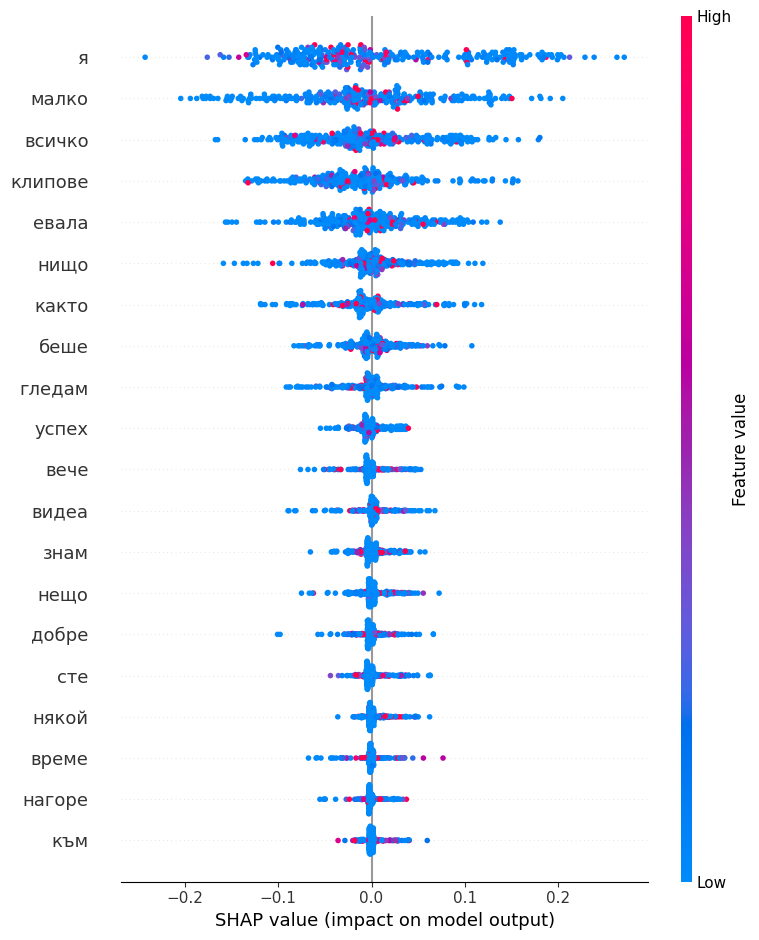

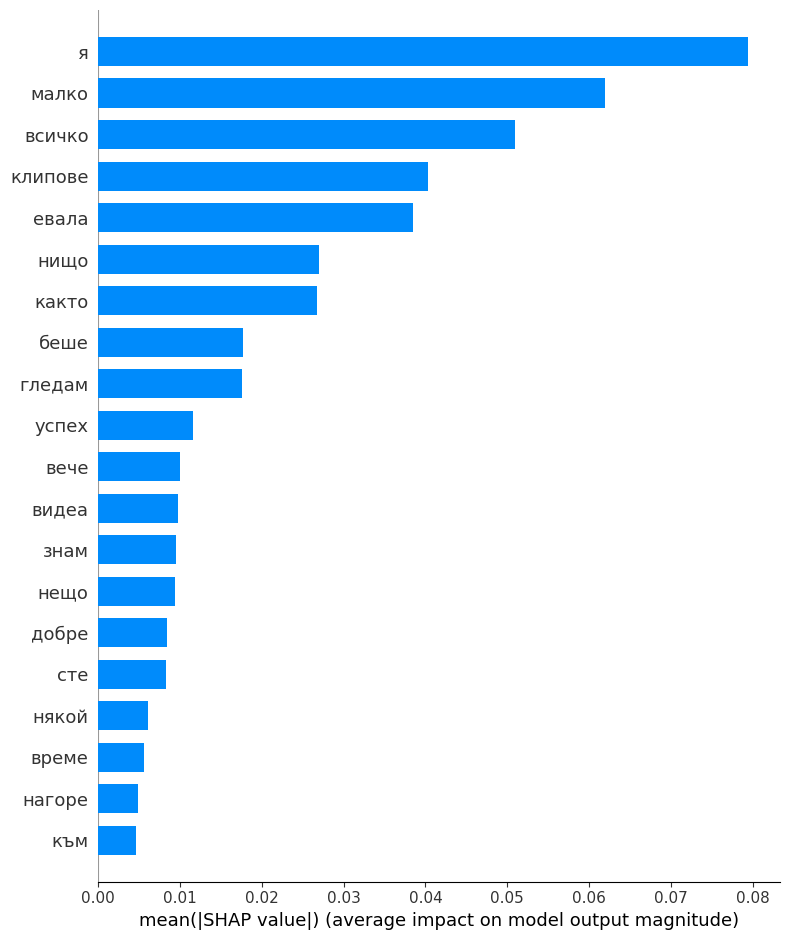

In [ ]:
explainer_dnn_emb, shap_values_dnn_emb = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)

# Gated Recurrence Unit(GRU)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# Set the maximum number of words and sequence length
max_words = 10000
max_len = 100

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

# # Build GRU model
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# # Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2)

# # Predict on the test set
y_test_predicted_labels = (model.predict(X_test_padded) > 0.5).astype(int)

# # Calculate metrics
accuracy = accuracy_score(y_true_numeric, y_test_predicted_labels)
precision = precision_score(y_true_numeric, y_test_predicted_labels, average='binary')
recall = recall_score(y_true_numeric, y_test_predicted_labels, average='binary')
f1 = f1_score(y_true_numeric, y_test_predicted_labels, average='binary')

# Print the results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")


Epoch 1/10
15/15 [==============================] - 13s 621ms/step - loss: 0.6800 - accuracy: 0.6197 - val_loss: 0.8654 - val_accuracy: 0.0000e+00
Epoch 2/10
15/15 [==============================] - 7s 497ms/step - loss: 0.6413 - accuracy: 0.6261 - val_loss: 1.1618 - val_accuracy: 0.0000e+00
Epoch 3/10
15/15 [==============================] - 8s 498ms/step - loss: 0.5647 - accuracy: 0.6345 - val_loss: 1.0856 - val_accuracy: 0.0750
Epoch 4/10
15/15 [==============================] - 11s 726ms/step - loss: 0.3631 - accuracy: 0.8487 - val_loss: 0.8847 - val_accuracy: 0.7083
Epoch 5/10
15/15 [==============================] - 6s 418ms/step - loss: 0.1147 - accuracy: 0.9769 - val_loss: 1.7171 - val_accuracy: 0.6250
Epoch 6/10
15/15 [==============================] - 8s 558ms/step - loss: 0.0132 - accuracy: 0.9958 - val_loss: 1.1952 - val_accuracy: 0.7750
Epoch 7/10
15/15 [==============================] - 6s 399ms/step - loss: 0.0096 - accuracy: 0.9979 - val_loss: 1.6755 - val_accuracy: 0.6

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true_numeric, y_test_predicted_labels)

# Calculate classification report
class_report = classification_report(y_true_numeric, y_test_predicted_labels)

# Print the results
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")


Confusion Matrix:
[[118  32]
 [ 41 109]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76       150
           1       0.77      0.73      0.75       150

    accuracy                           0.76       300
   macro avg       0.76      0.76      0.76       300
weighted avg       0.76      0.76      0.76       300



In [ ]:
explainer_gru, shap_values_gru = explainable_AI(model,X_train_padded,list(ALL_WORDS),X_test_padded,shap.Explainer,False)